# Data Exploration

In [2]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')


sns.set_theme(style='whitegrid', palette='muted')
COLORS = {'no': '#e07b54', 'yes': '#378add'}


df_path = r"C:\Users\divye\Data_science_projects\5qaNUcRSLjHZ5anY\data\term-deposit-marketing-2020.csv"

df = pd.read_csv(df_path)

df.head(10)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,no
5,35,management,married,tertiary,no,231,yes,no,unknown,5,may,139,1,no
6,28,management,single,tertiary,no,447,yes,yes,unknown,5,may,217,1,no
7,42,entrepreneur,divorced,tertiary,yes,2,yes,no,unknown,5,may,380,1,no
8,58,retired,married,primary,no,121,yes,no,unknown,5,may,50,1,no
9,43,technician,single,secondary,no,593,yes,no,unknown,5,may,55,1,no


In [3]:
df.isna().sum()

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
y            0
dtype: int64

# EDA 

In [4]:
eda_df = df.copy()

print(eda_df['marital'].value_counts())
print(eda_df['education'].value_counts())
print(eda_df['default'].value_counts())


marital
married     24386
single      10889
divorced     4725
Name: count, dtype: int64
education
secondary    20993
tertiary     11206
primary       6270
unknown       1531
Name: count, dtype: int64
default
no     39191
yes      809
Name: count, dtype: int64


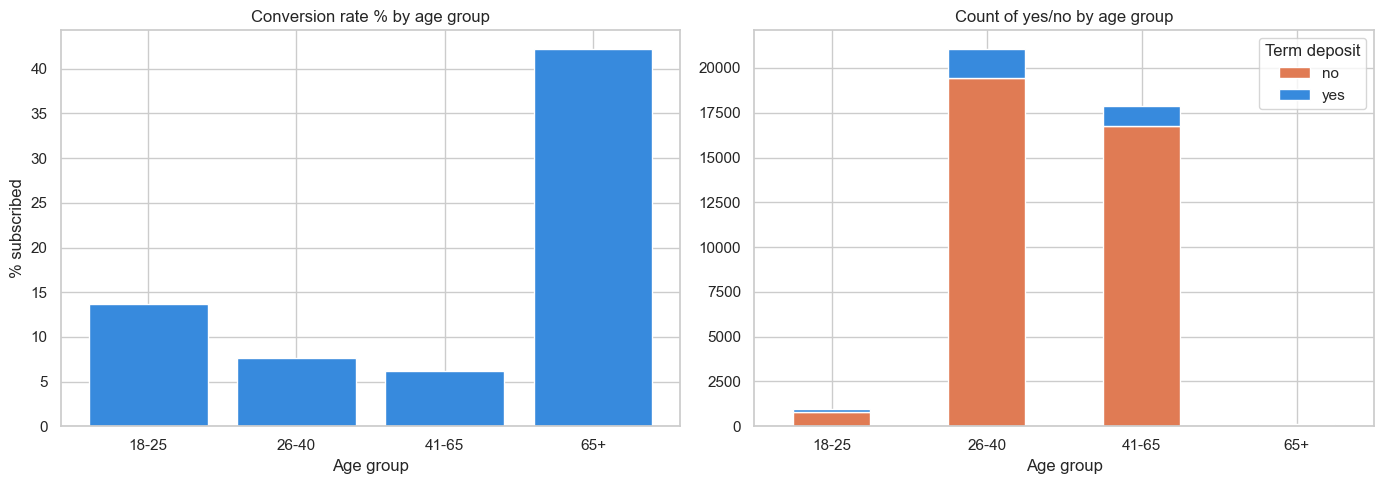

In [5]:
eda_df['age_group'] = pd.cut(eda_df['age'],
    bins=[17, 25, 40, 65, 100],
    labels=['18-25', '26-40', '41-65', '65+'])

# conversion rate per age group
age_conv = (eda_df.groupby('age_group', observed=True)['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reset_index(name='conversion_rate'))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- plot 1: conversion rate bar ---
axes[0].bar(age_conv['age_group'].astype(str),
         age_conv['conversion_rate'],
         color='#378add', edgecolor='white')
axes[0].set_title('Conversion rate % by age group')
axes[0].set_xlabel('Age group')
axes[0].set_ylabel('% subscribed')

# --- plot 2: stacked count bar ---
age_counts = pd.crosstab(eda_df['age_group'], eda_df['y'])
age_counts.plot(kind='bar', stacked=True, ax=axes[1],
               color=['#e07b54', '#378add'], edgecolor='white')
axes[1].set_title('Count of yes/no by age group')
axes[1].set_xlabel('Age group')
axes[1].legend(title='Term deposit')
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

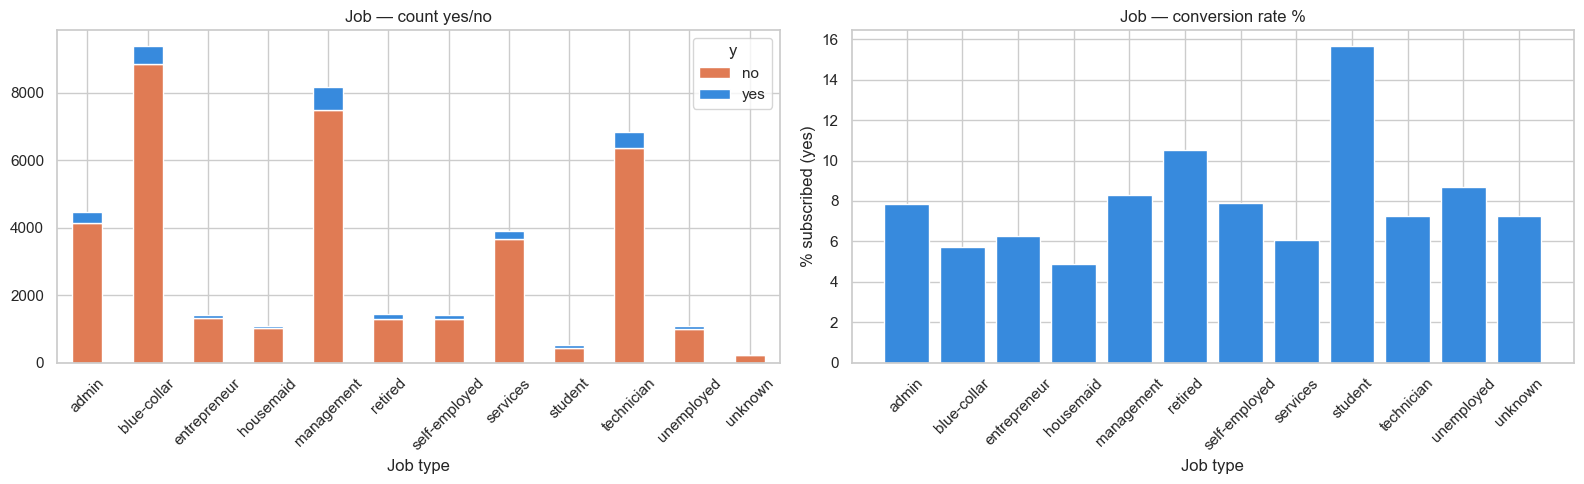

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

job_order = sorted(eda_df['job'].unique().tolist())

# Stacked count bar
job_counts = pd.crosstab(eda_df['job'], eda_df['y'])[
    ['no', 'yes']].reindex(job_order)
job_counts.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[0].set_title('Job — count yes/no')
axes[0].set_xlabel('Job type')
axes[0].tick_params(axis='x', rotation=45)

# Conversion rate bar
job_conv = (eda_df.groupby('job')['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reindex(job_order)
              .reset_index(name='pct_yes'))
axes[1].bar(job_conv['job'], job_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[1].set_title('Job — conversion rate %')
axes[1].set_xlabel('Job type')
axes[1].set_ylabel('% subscribed (yes)')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

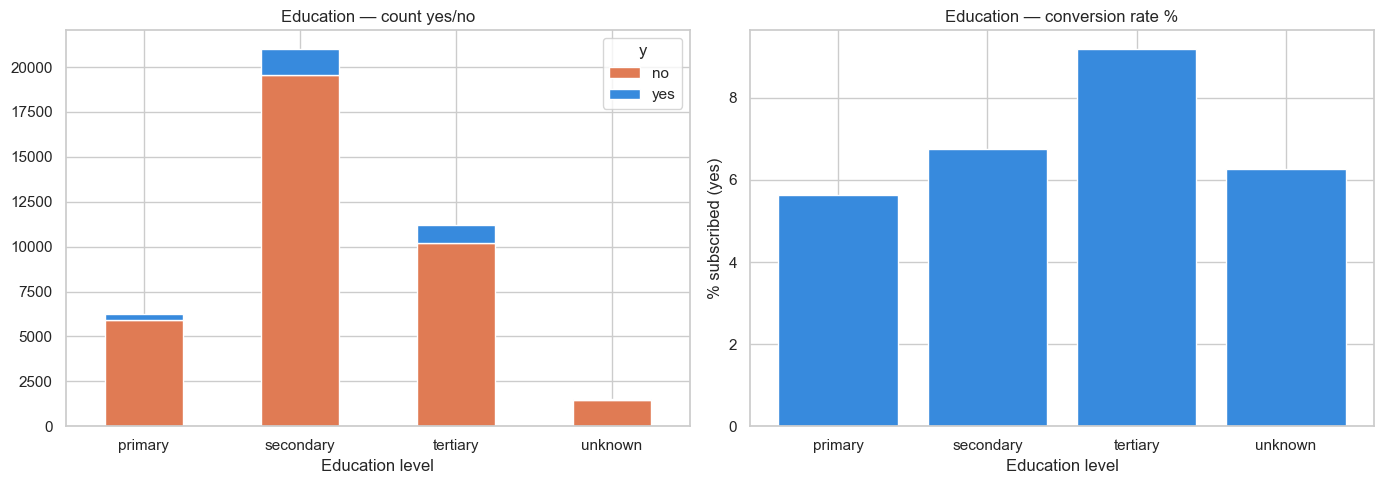

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

edu_order = ['primary', 'secondary', 'tertiary', 'unknown']

# Stacked count bar
edu_counts = pd.crosstab(eda_df['education'], eda_df['y'])[
    ['no', 'yes']].reindex(edu_order)
edu_counts.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[0].set_title('Education — count yes/no')
axes[0].set_xlabel('Education level')
axes[0].tick_params(axis='x', rotation=0)

# Conversion rate bar
edu_conv = (eda_df.groupby('education')['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reindex(edu_order)
              .reset_index(name='pct_yes'))
axes[1].bar(edu_conv['education'], edu_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[1].set_title('Education — conversion rate %')
axes[1].set_xlabel('Education level')
axes[1].set_ylabel('% subscribed (yes)')

plt.tight_layout()
plt.show()

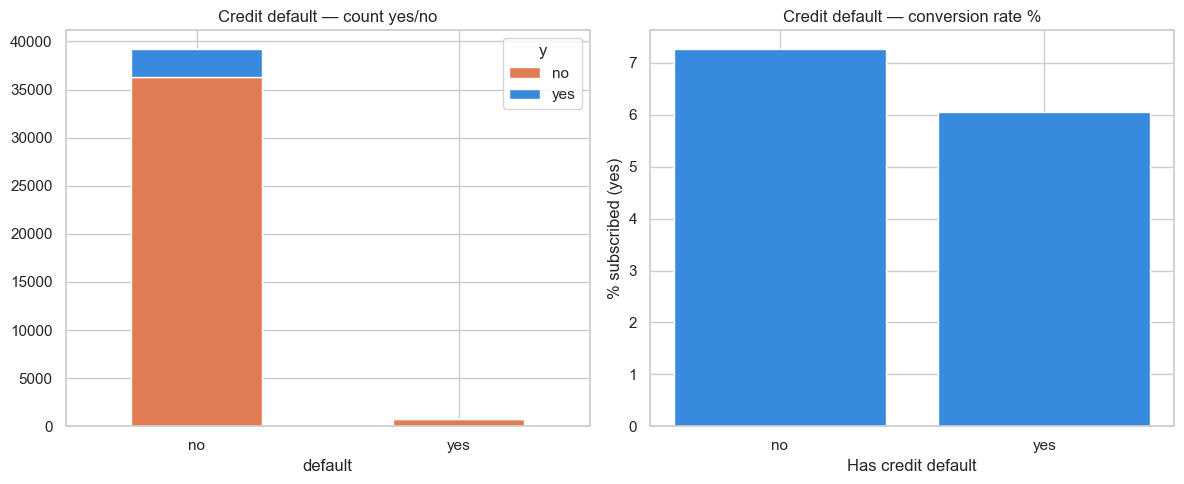

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

def_counts = pd.crosstab(eda_df['default'], eda_df['y'])[['no', 'yes']]
def_counts.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[0].set_title('Credit default — count yes/no')
axes[0].tick_params(axis='x', rotation=0)

def_conv = (eda_df.groupby('default')['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reset_index(name='pct_yes'))
axes[1].bar(def_conv['default'], def_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[1].set_title('Credit default — conversion rate %')
axes[1].set_xlabel('Has credit default')
axes[1].set_ylabel('% subscribed (yes)')

plt.tight_layout()
plt.show()

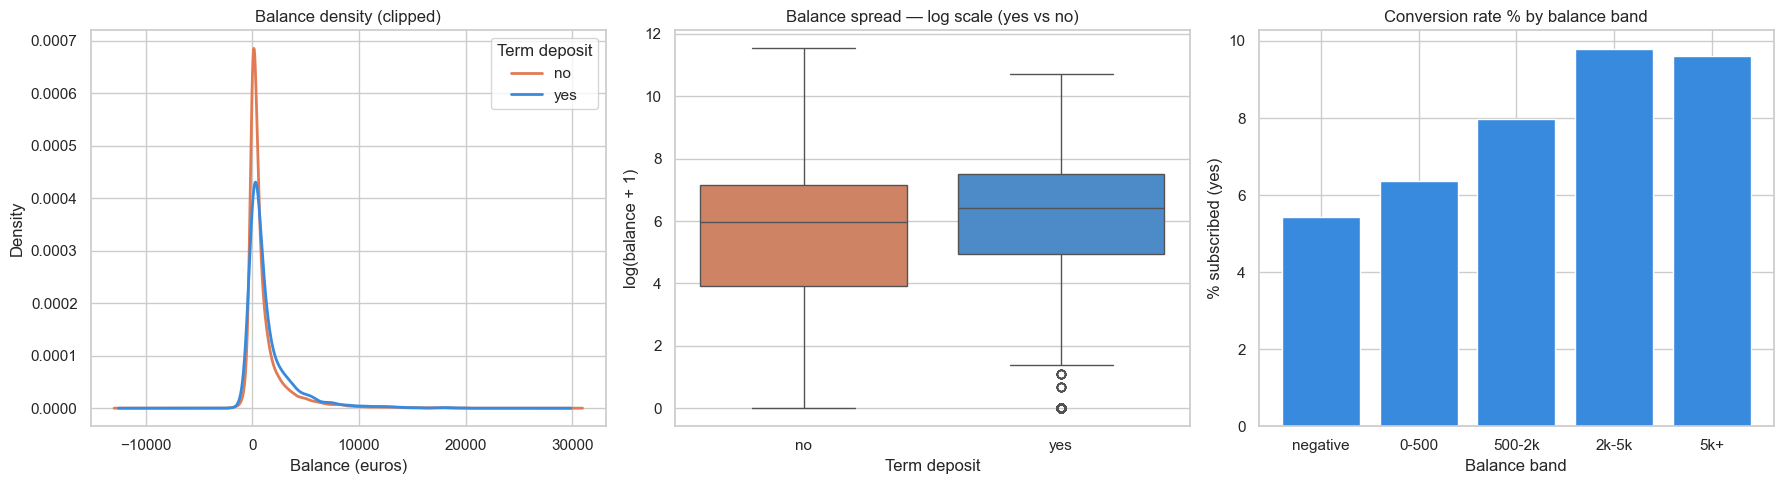

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# KDE — clip extreme outliers for readability
bal_clip = eda_df[eda_df['balance'].between(-2000, 20000)]
for label, grp in bal_clip.groupby('y')['balance']:
    grp.plot.kde(ax=axes[0], label=label,
               linewidth=2, color=COLORS[label])
axes[0].set_title('Balance density (clipped)')
axes[0].set_xlabel('Balance (euros)')
axes[0].legend(title='Term deposit')

# shift balance so log works (balance can be 0 or negative)
eda_df['balance_log'] = np.log1p(eda_df['balance'].clip(lower=0))

sns.boxplot(data=eda_df, x='y', y='balance_log', ax=axes[1],
            order=['no', 'yes'], palette=COLORS)
axes[1].set_title('Balance spread — log scale (yes vs no)')
axes[1].set_xlabel('Term deposit')
axes[1].set_ylabel('log(balance + 1)')

# Balance bins conversion rate
eda_df['bal_group'] = pd.cut(eda_df['balance'],
    bins=[-10000, 0, 500, 2000, 5000, 100000],
    labels=['negative', '0-500', '500-2k', '2k-5k', '5k+'])
bal_conv = (eda_df.groupby('bal_group', observed=True)['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reset_index(name='pct_yes'))
axes[2].bar(bal_conv['bal_group'].astype(str),
         bal_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[2].set_title('Conversion rate % by balance band')
axes[2].set_xlabel('Balance band')
axes[2].set_ylabel('% subscribed (yes)')

plt.tight_layout()
plt.show()

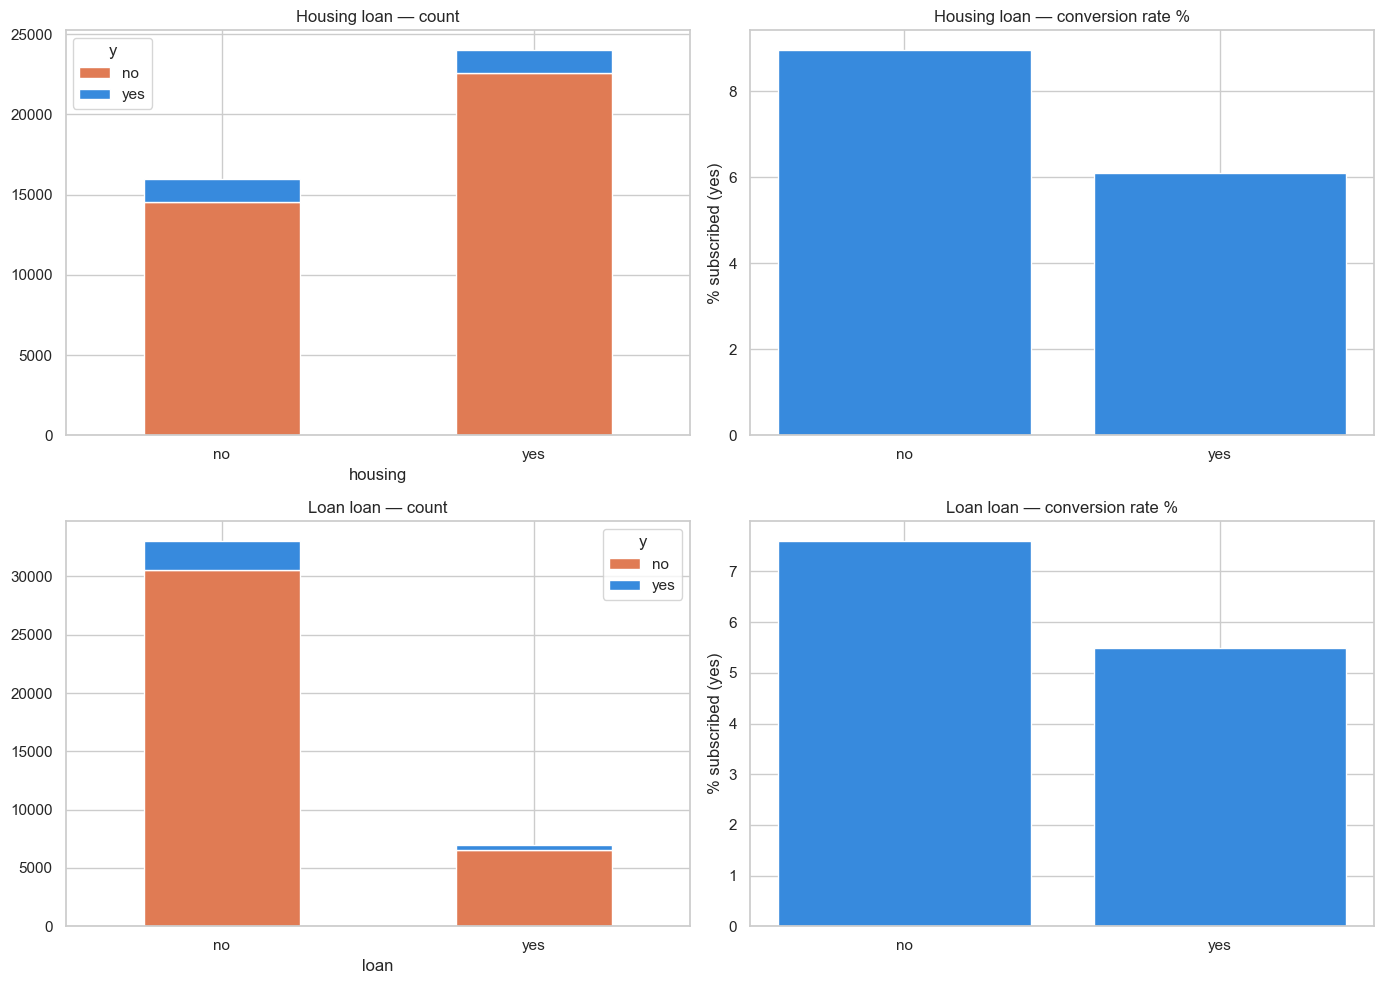

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for i, col in enumerate(['housing', 'loan']):
    # stacked count
    counts = pd.crosstab(eda_df[col], eda_df['y'])[['no', 'yes']]
    counts.plot(kind='bar', stacked=True, ax=axes[i][0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
    axes[i][0].set_title(f'{col.title()} loan — count')
    axes[i][0].tick_params(axis='x', rotation=0)

    # conversion rate
    conv = (eda_df.groupby(col)['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reset_index(name='pct_yes'))
    axes[i][1].bar(conv[col], conv['pct_yes'],
             color='#378add', edgecolor='white')
    axes[i][1].set_title(f'{col.title()} loan — conversion rate %')
    axes[i][1].set_ylabel('% subscribed (yes)')

plt.tight_layout()
plt.show()

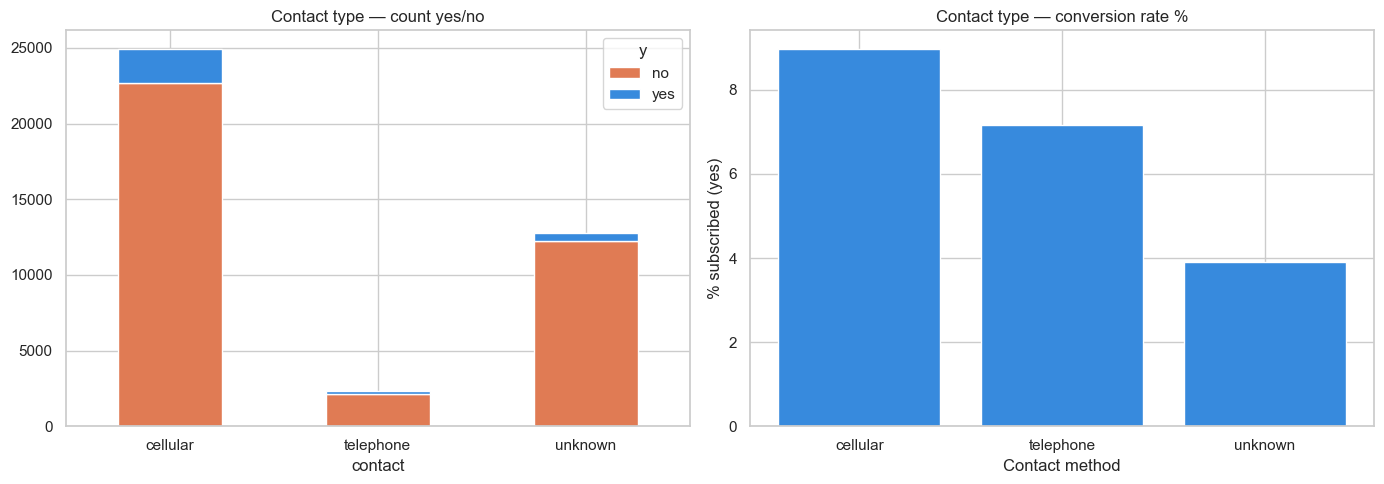

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ct_counts = pd.crosstab(eda_df['contact'], eda_df['y'])[['no', 'yes']]
ct_counts.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[0].set_title('Contact type — count yes/no')
axes[0].tick_params(axis='x', rotation=0)

ct_conv = (eda_df.groupby('contact')['y']
             .apply(lambda x: (x == 'yes').mean() * 100)
             .reset_index(name='pct_yes'))
axes[1].bar(ct_conv['contact'], ct_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[1].set_title('Contact type — conversion rate %')
axes[1].set_xlabel('Contact method')
axes[1].set_ylabel('% subscribed (yes)')

plt.tight_layout()
plt.show()

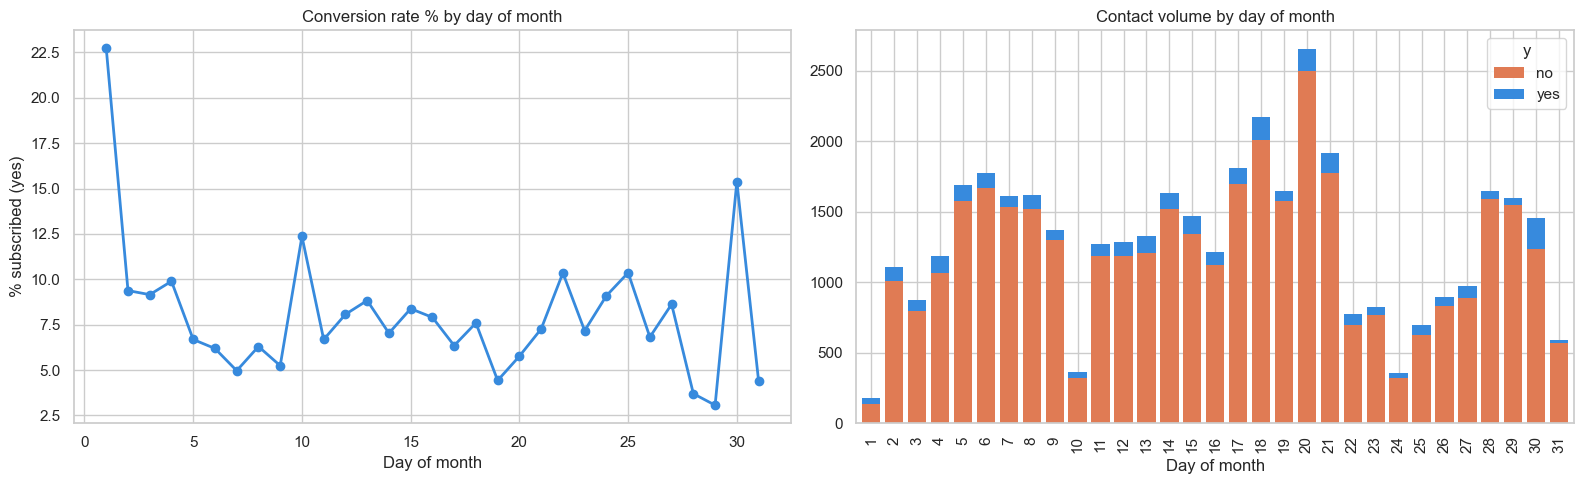

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Average conversion by day
day_conv = (eda_df.groupby('day')['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reset_index(name='pct_yes'))
axes[0].plot(day_conv['day'], day_conv['pct_yes'],
           marker='o', color='#378add', linewidth=2)
axes[0].set_title('Conversion rate % by day of month')
axes[0].set_xlabel('Day of month')
axes[0].set_ylabel('% subscribed (yes)')

# Volume of contacts per day
day_vol = eda_df.groupby(['day', 'y']).size().unstack(fill_value=0)
day_vol.plot(kind='bar', stacked=True, ax=axes[1],
            color=[COLORS['no'], COLORS['yes']],
            edgecolor='none', width=0.8)
axes[1].set_title('Contact volume by day of month')
axes[1].set_xlabel('Day of month')
axes[1].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()

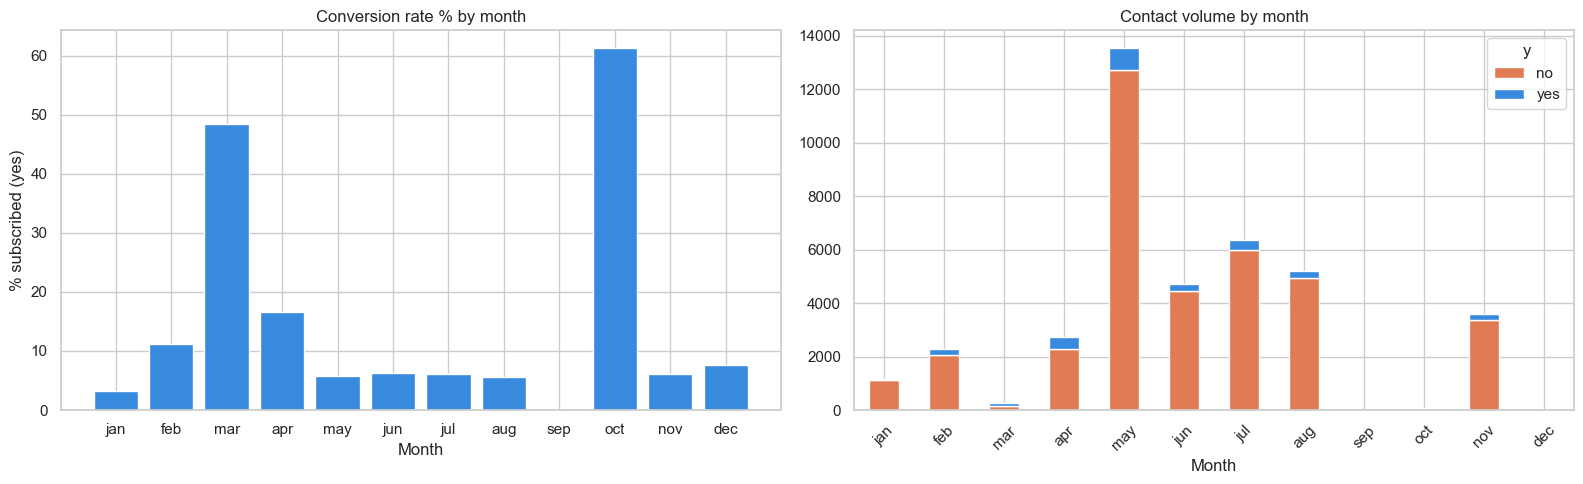

In [13]:
month_order = ['jan','feb','mar','apr','may','jun',
               'jul','aug','sep','oct','nov','dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

month_conv = (eda_df.groupby('month')['y']
                .apply(lambda x: (x == 'yes').mean() * 100)
                .reindex(month_order)
                .reset_index(name='pct_yes'))
axes[0].bar(month_conv['month'], month_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[0].set_title('Conversion rate % by month')
axes[0].set_xlabel('Month')
axes[0].set_ylabel('% subscribed (yes)')

month_vol = (eda_df.groupby(['month', 'y'])
               .size().unstack(fill_value=0)
               .reindex(month_order))
month_vol.plot(kind='bar', stacked=True, ax=axes[1],
              color=[COLORS['no'], COLORS['yes']],
              edgecolor='white')
axes[1].set_title('Contact volume by month')
axes[1].set_xlabel('Month')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

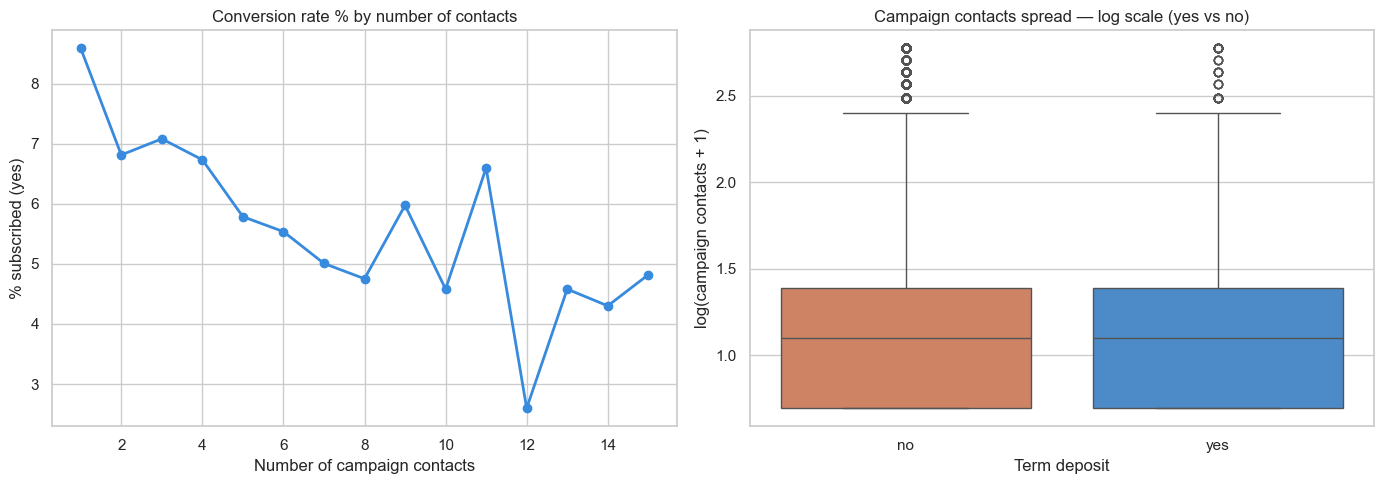

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# clip outliers — most contacts are under 15
camp_clip = eda_df[eda_df['campaign'] <= 15]

camp_conv = (camp_clip.groupby('campaign')['y']
               .apply(lambda x: (x == 'yes').mean() * 100)
               .reset_index(name='pct_yes'))
axes[0].plot(camp_conv['campaign'], camp_conv['pct_yes'],
           marker='o', color='#378add', linewidth=2)
axes[0].set_title('Conversion rate % by number of contacts')
axes[0].set_xlabel('Number of campaign contacts')
axes[0].set_ylabel('% subscribed (yes)')

# clip first then log transform
eda_df['campaign_log'] = np.log1p(eda_df['campaign'].clip(upper=15))

sns.boxplot(data=eda_df, x='y', y='campaign_log', ax=axes[1],
            order=['no', 'yes'], palette=COLORS)
axes[1].set_title('Campaign contacts spread — log scale (yes vs no)')
axes[1].set_xlabel('Term deposit')
axes[1].set_ylabel('log(campaign contacts + 1)')

plt.tight_layout()
plt.show()

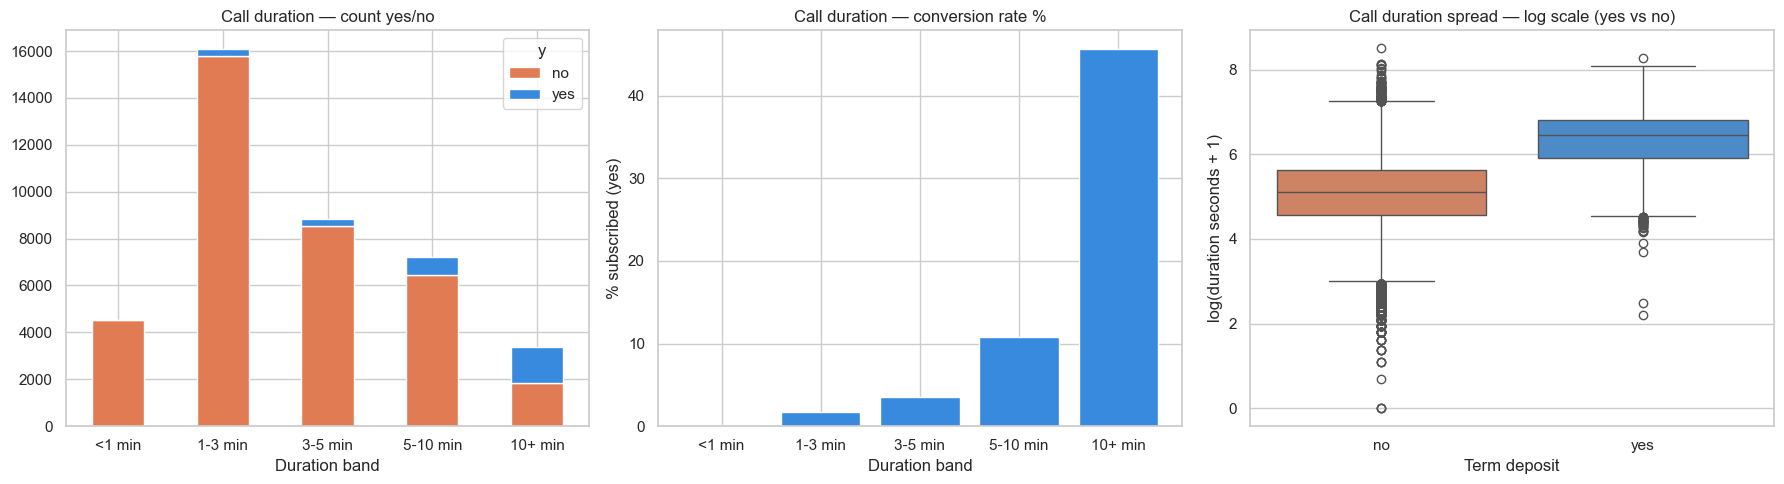

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# bin duration in seconds into readable groups
eda_df['dur_group'] = pd.cut(eda_df['duration'],
    bins=[0, 60, 180, 300, 600, 99999],
    labels=['<1 min', '1-3 min', '3-5 min', '5-10 min', '10+ min'])

dur_order = ['<1 min', '1-3 min', '3-5 min', '5-10 min', '10+ min']

# stacked count bar
dur_counts = pd.crosstab(eda_df['dur_group'], eda_df['y'])[
    ['no', 'yes']].reindex(dur_order)
dur_counts.plot(kind='bar', stacked=True, ax=axes[0],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[0].set_title('Call duration — count yes/no')
axes[0].set_xlabel('Duration band')
axes[0].tick_params(axis='x', rotation=0)

# conversion rate bar
dur_conv = (eda_df.groupby('dur_group', observed=True)['y']
              .apply(lambda x: (x == 'yes').mean() * 100)
              .reindex(dur_order)
              .reset_index(name='pct_yes'))
axes[1].bar(dur_conv['dur_group'].astype(str), dur_conv['pct_yes'],
         color='#378add', edgecolor='white')
axes[1].set_title('Call duration — conversion rate %')
axes[1].set_xlabel('Duration band')
axes[1].set_ylabel('% subscribed (yes)')
axes[1].tick_params(axis='x', rotation=0)

# box plot with log scale to handle skew
eda_df['duration_log'] = np.log1p(eda_df['duration'])
sns.boxplot(data=eda_df, x='y', y='duration_log', ax=axes[2],
            order=['no', 'yes'], palette=COLORS)
axes[2].set_title('Call duration spread — log scale (yes vs no)')
axes[2].set_xlabel('Term deposit')
axes[2].set_ylabel('log(duration seconds + 1)')

plt.tight_layout()
plt.show()

IQR upper fence cap : 632 seconds
IQR lower fence cap : -220 seconds
Values capped       : 3000 rows


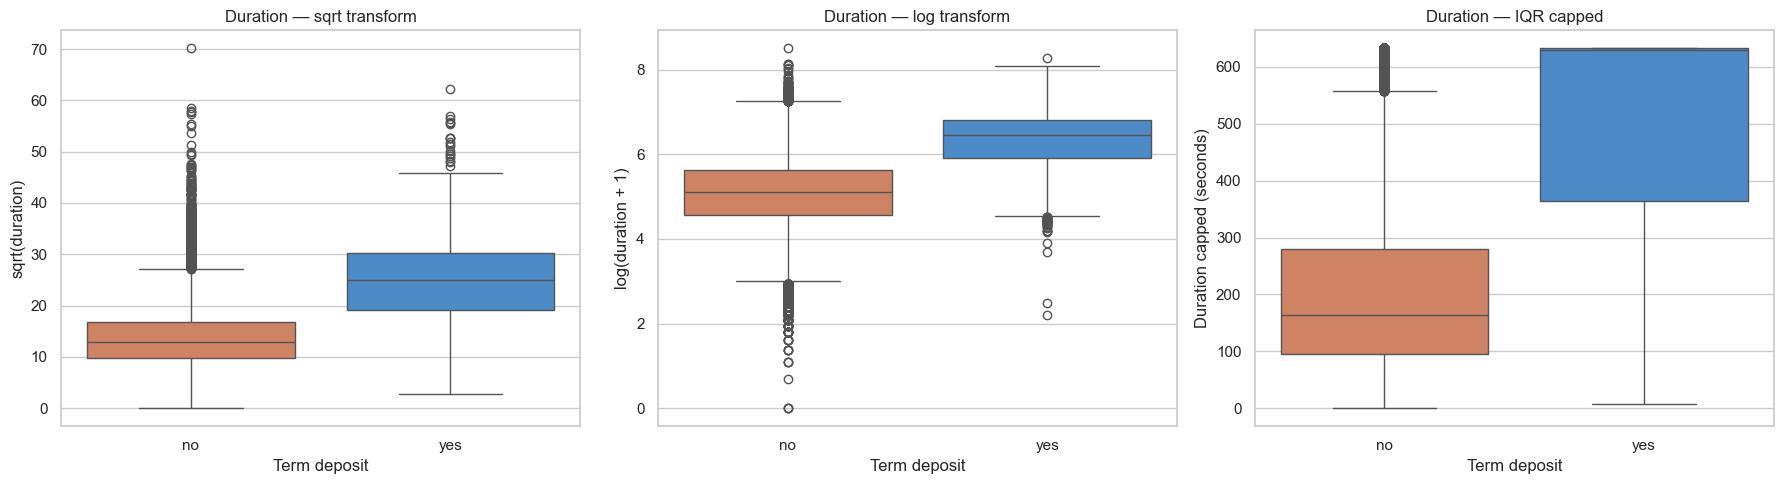

In [16]:
# three transformations to compare
eda_df['duration_log']  = np.log1p(eda_df['duration'])
eda_df['duration_sqrt'] = np.sqrt(eda_df['duration'])

# IQR capping — cap anything beyond 1.5*IQR at the fence
Q1  = eda_df['duration'].quantile(0.25)
Q3  = eda_df['duration'].quantile(0.75)
IQR = Q3 - Q1
upper_fence = Q3 + 1.5 * IQR
lower_fence = Q1 - 1.5 * IQR

eda_df['duration_capped'] = eda_df['duration'].clip(
    lower=lower_fence, upper=upper_fence)

print(f"IQR upper fence cap : {upper_fence:.0f} seconds")
print(f"IQR lower fence cap : {lower_fence:.0f} seconds")
print(f"Values capped       : {(eda_df['duration'] > upper_fence).sum()} rows")

# plot all three side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# sqrt
sns.boxplot(data=eda_df, x='y', y='duration_sqrt', ax=axes[0],
            order=['no', 'yes'], palette=COLORS)
axes[0].set_title('Duration — sqrt transform')
axes[0].set_xlabel('Term deposit')
axes[0].set_ylabel('sqrt(duration)')

# log
sns.boxplot(data=eda_df, x='y', y='duration_log', ax=axes[1],
            order=['no', 'yes'], palette=COLORS)
axes[1].set_title('Duration — log transform')
axes[1].set_xlabel('Term deposit')
axes[1].set_ylabel('log(duration + 1)')

# IQR capped
sns.boxplot(data=eda_df, x='y', y='duration_capped', ax=axes[2],
            order=['no', 'yes'], palette=COLORS)
axes[2].set_title('Duration — IQR capped')
axes[2].set_xlabel('Term deposit')
axes[2].set_ylabel('Duration capped (seconds)')

plt.tight_layout()
plt.show()

In [17]:
## Feature Engineering
eda_df['edu_job'] = eda_df['education'] + '_' + eda_df['job']
  # secondary_technician vs secondary_blue-collar behave differently

eda_df['debt_burden'] = (
      (eda_df['housing'] == 'yes').astype(int) +
      (eda_df['loan'] == 'yes').astype(int)
  )

high_conv_months = ['mar', 'apr', 'oct']
eda_df['is_high_conv_month'] = eda_df['month'].isin(high_conv_months).astype(int)

eda_df['is_first_contact'] = (eda_df['campaign'] == 1).astype(int)
eda_df['over_contacted']   = (eda_df['campaign'] > 3).astype(int)


# 📊 EDA Summary — Bank Term Deposit Campaign

---

## 1. Age
- **65+** → highest conversion (~42%) but tiny sample — not scalable alone
- **18-25** → decent conversion (~13.5%) but underreached by the campaign
- **26-40** → largest group (~21,000) but only 7.5% conversion
- **41-65** → second largest (~18,000) with worst conversion at 6.3%
- **Insight:** Campaign is spending most effort on the least receptive age groups

---

## 2. Education
- **Tertiary** → best conversion (~9%) — university educated, financially literate
- **Secondary** → most targeted (~21,000) but average conversion (~7%)
- **Primary** → lowest conversion (~6%)
- **Unknown** → treat carefully, may need imputation
- **Feature Engineering Tip:** Cross secondary with job type
```python
  eda_df['edu_job'] = eda_df['education'] + '_' + eda_df['job']
  # secondary_technician vs secondary_blue-collar behave differently
```

---

## 3. Balance
- Consistent positive signal — higher balance = higher conversion
- Conversion rises from **5.4% (negative balance)** → **9.7% (2k-5k band)**
- Heavy right skew handled with **log transformation**
- Moderate predictor on its own but reliable direction

---

## 4. Housing & Personal Loan
- Clients **without any loan** convert significantly better
- **Housing loan** gap: 8.9% (no loan) vs 6.1% (has loan) — stronger signal
- **Personal loan** gap: 7.4% (no loan) vs 5.4% (has loan) — weaker signal
- Personal loan holders are a minority (~6,500 of 40,000)
- **Feature Engineering Tip:** Combine both into a debt burden score
```python
  eda_df['debt_burden'] = (
      (eda_df['housing'] == 'yes').astype(int) +
      (eda_df['loan'] == 'yes').astype(int)
  )
  # 0 = no loans, 1 = one loan, 2 = both loans
```

---

## 5. Contact Type
- **Cellular** → best channel: highest volume (~25,000) AND best conversion (~9%)
- **Telephone** → small volume (~2,500) with decent conversion (~7.2%)
- **Unknown** → ~12,500 records (nearly a third of data), worst conversion (~4%)
- Unknown kept as its own category — likely a missing data pattern the model can learn from

---

## 6. Day & Month
- **Day of month** → weak and noisy signal, no consistent pattern
- **Best months** → March (~48%), October (~61%) but very low volume
- **Worst months** → May has ~13,500 contacts but only 6% conversion
- **Insight:** Campaign calendar needs rethinking — heaviest effort in worst months
- **Feature Engineering Tip:**
```python
  high_conv_months = ['mar', 'apr', 'oct']
  eda_df['is_high_conv_month'] = eda_df['month'].isin(high_conv_months).astype(int)
```

---

## 7. Campaign Contacts
- First contact → **8.5% conversion** — best result
- Conversion drops sharply after 3 contacts
- Yes and No groups have almost identical contact distributions
- **Insight:** Calling the same person repeatedly is wasted effort
```python
  eda_df['is_first_contact'] = (eda_df['campaign'] == 1).astype(int)
  eda_df['over_contacted']   = (eda_df['campaign'] > 3).astype(int)
```

---

## 8. Call Duration ⚠️
- **Strongest predictor** in the entire dataset
- Clear step-up pattern:

| Duration | Conversion |
|----------|------------|
| < 1 min  | ~0%        |
| 1-3 min  | ~2%        |
| 3-5 min  | ~4%        |
| 5-10 min | ~11%       |
| 10+ min  | ~45%       |

- **Critical Warning — Data Leakage Risk:**
  > Duration is only known **after** the call ends. In real deployment the model cannot use this feature because you do not know call length before making the call.
- **Recommendation:** Train two versions
  - ✅ **With duration** — shows ceiling model performance
  - ✅ **Without duration** — real world deployable model

---

## 9. Credit Default
- Vast majority have no default (~39,000 vs ~800)
- Conversion gap is small: 7.3% (no default) vs 6% (has default)
- Heavily imbalanced column — weak standalone predictor
- Worth keeping as a feature but not a dominant signal

---

## Class Imbalance
| Class | Count | % |
|-------|-------|---|
| No    | 37,104 | 92.8% |
| Yes   | 2,896  | 7.2%  |

- Model must focus on **Recall of YES** — missing a real customer is costlier than a false alarm
- Use **threshold tuning** (lower from 0.5 → 0.3) to catch more yes cases

In [18]:
eda_df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'y',
       'age_group', 'balance_log', 'bal_group', 'campaign_log', 'dur_group',
       'duration_log', 'duration_sqrt', 'duration_capped', 'edu_job',
       'debt_burden', 'is_high_conv_month', 'is_first_contact',
       'over_contacted'],
      dtype='str')

# SHAP Analysis where the client has been contacted once only in the campaign.

Total dataset      : 40000 rows
Layer 1 (campaign==1): 14718 rows
Removed            : 25282 rows

Columns after drop: ['age', 'job', 'marital', 'education', 'default', 'balance', 'housing', 'loan', 'contact', 'day', 'month', 'y', 'age_group', 'balance_log', 'bal_group', 'edu_job', 'debt_burden', 'is_high_conv_month', 'is_first_contact', 'over_contacted']

Demographic features  : ['age', 'age_group', 'job', 'marital', 'education', 'default', 'balance_log', 'bal_group', 'housing', 'loan']
Call history features : ['month', 'day', 'contact']
Total features        : 13

Target distribution (first contact only):
  no  : 13454 (91.4%)
  yes : 1264 (8.6%)

   SECTION 1 — FULL EDA (Layer 1, no duration)


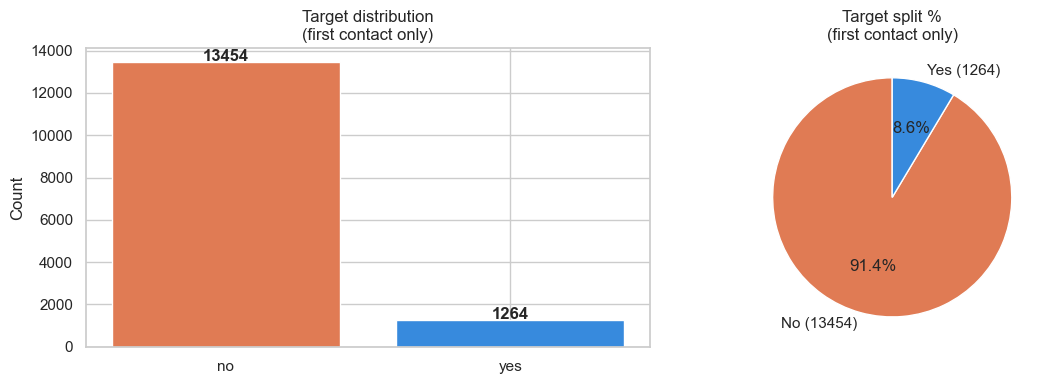

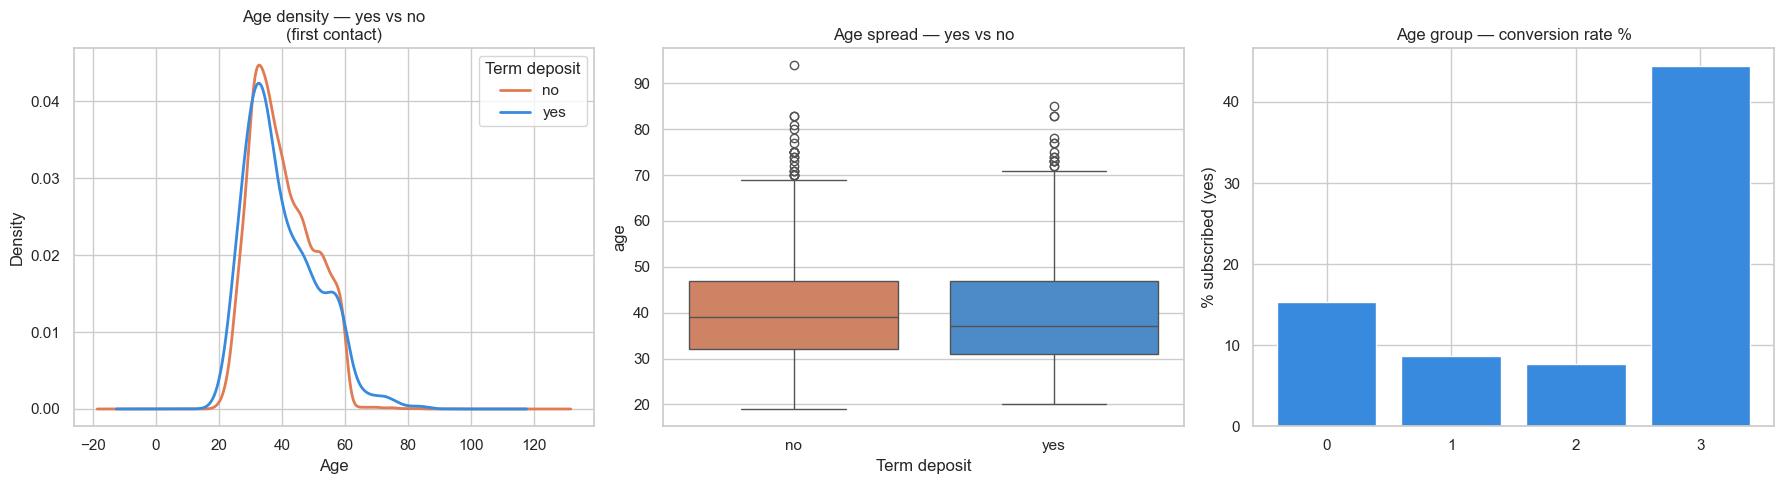

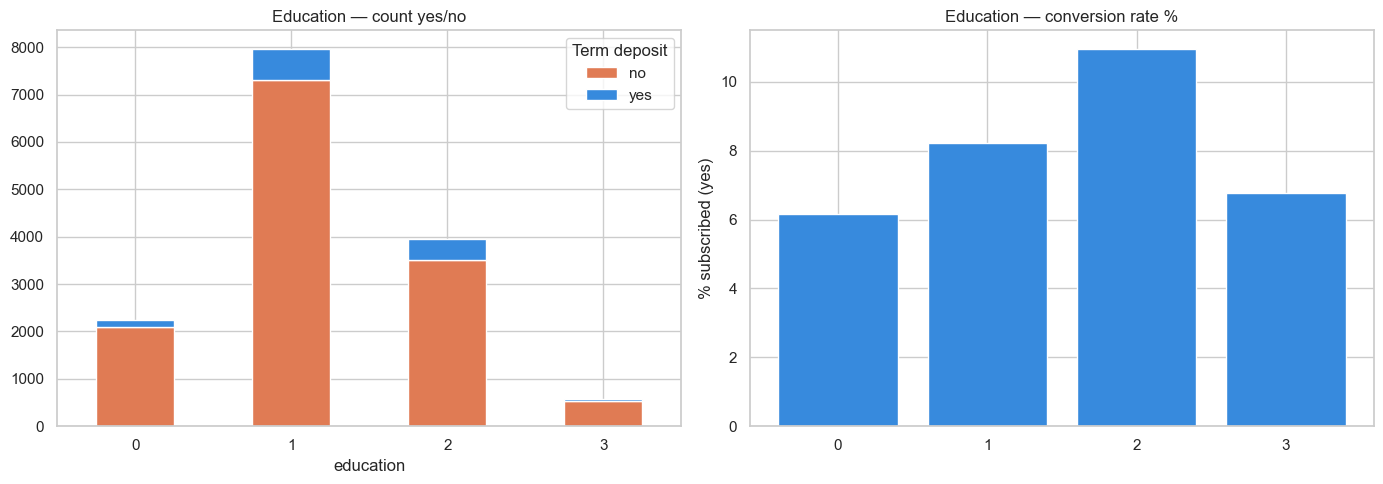

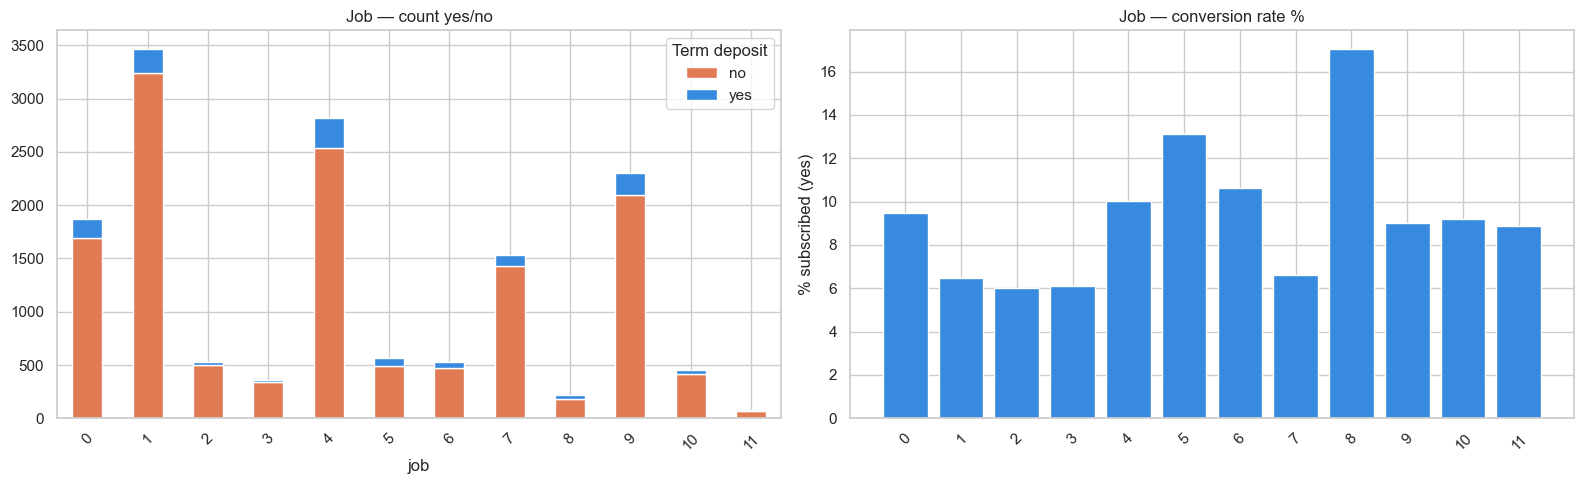

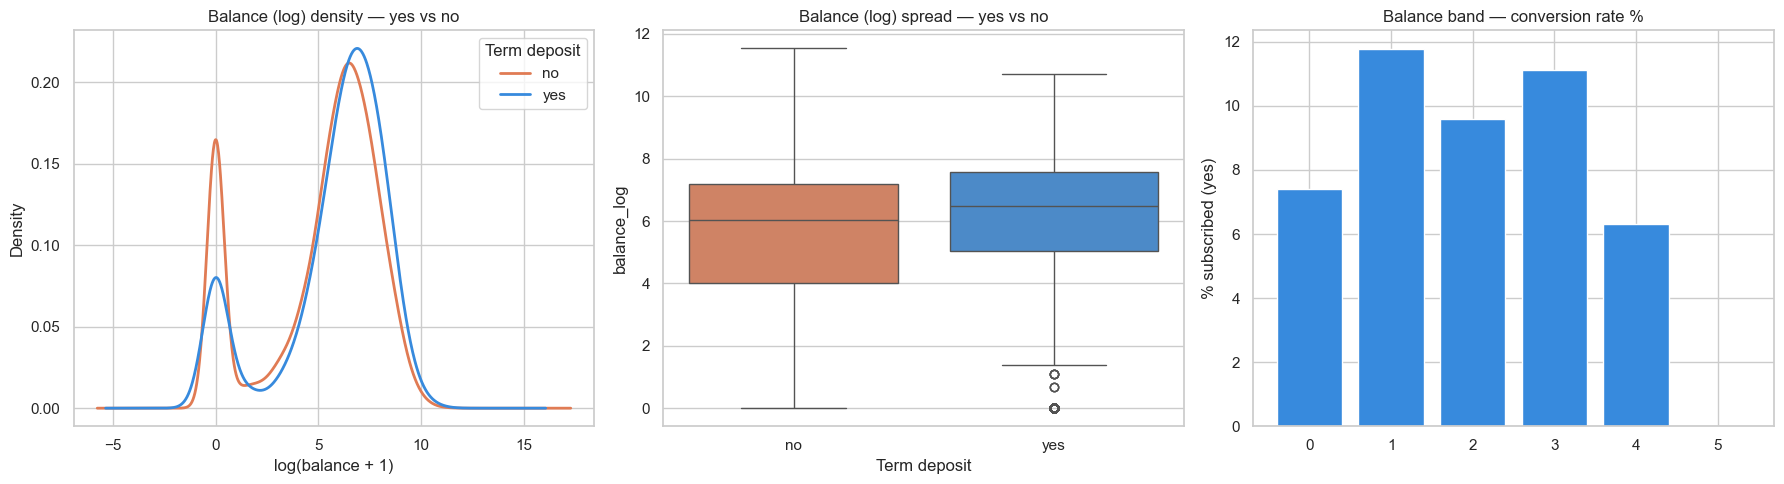

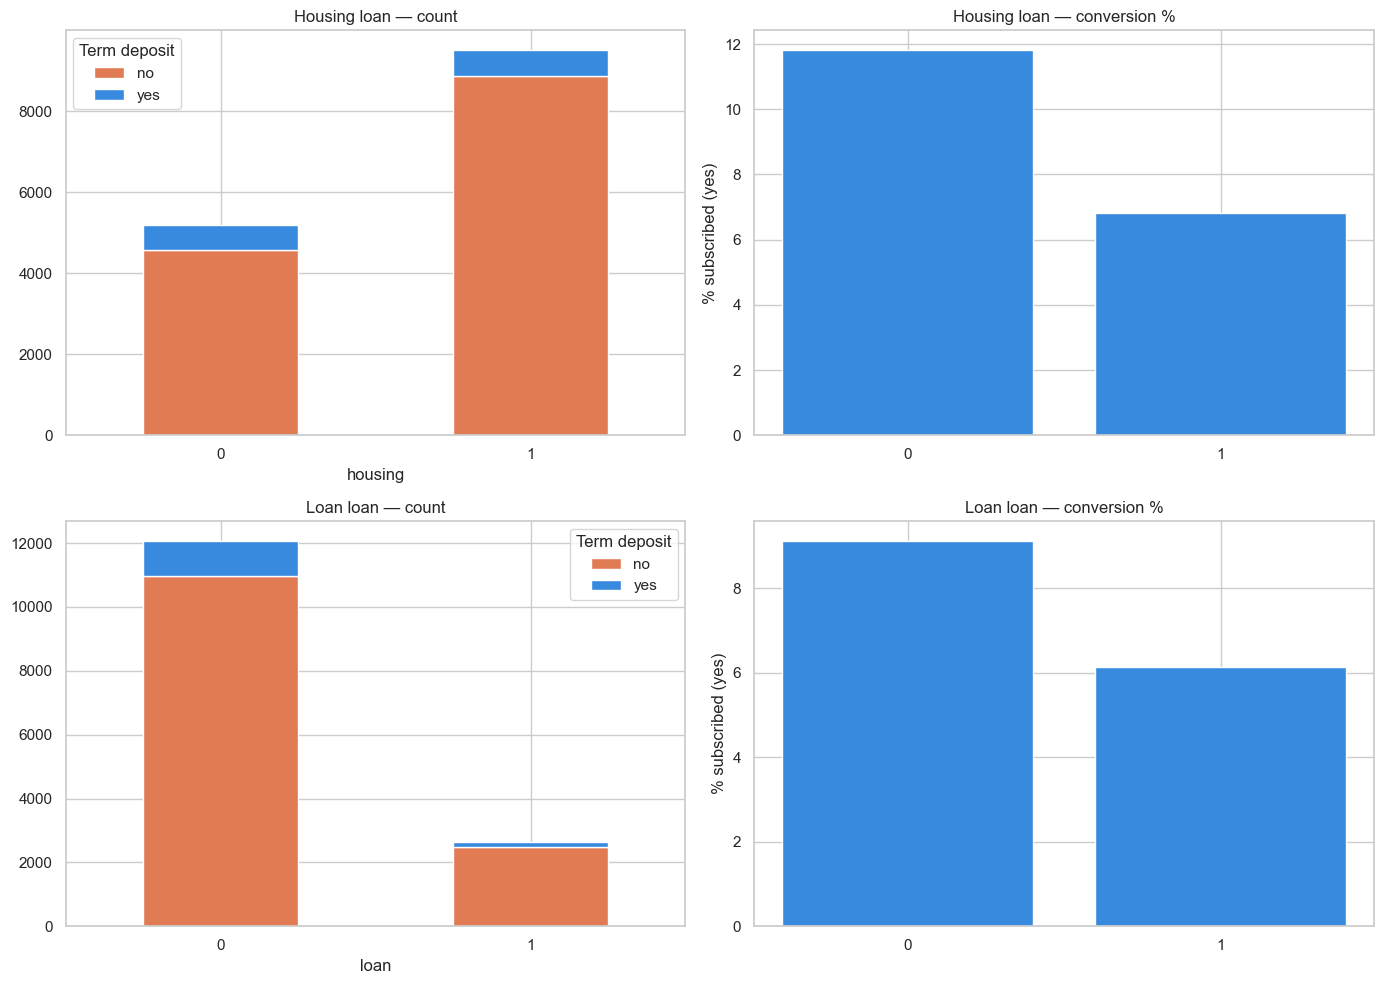

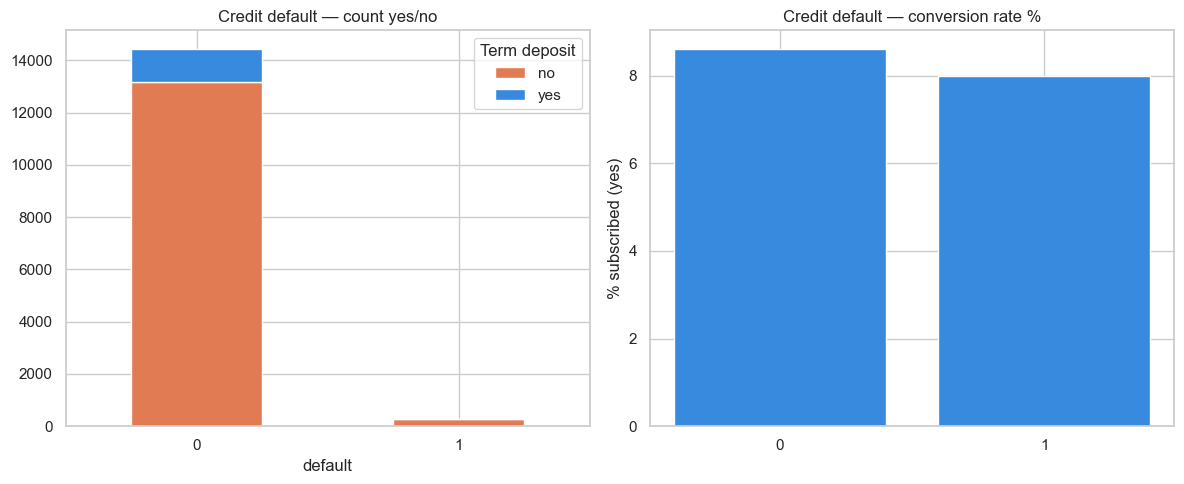

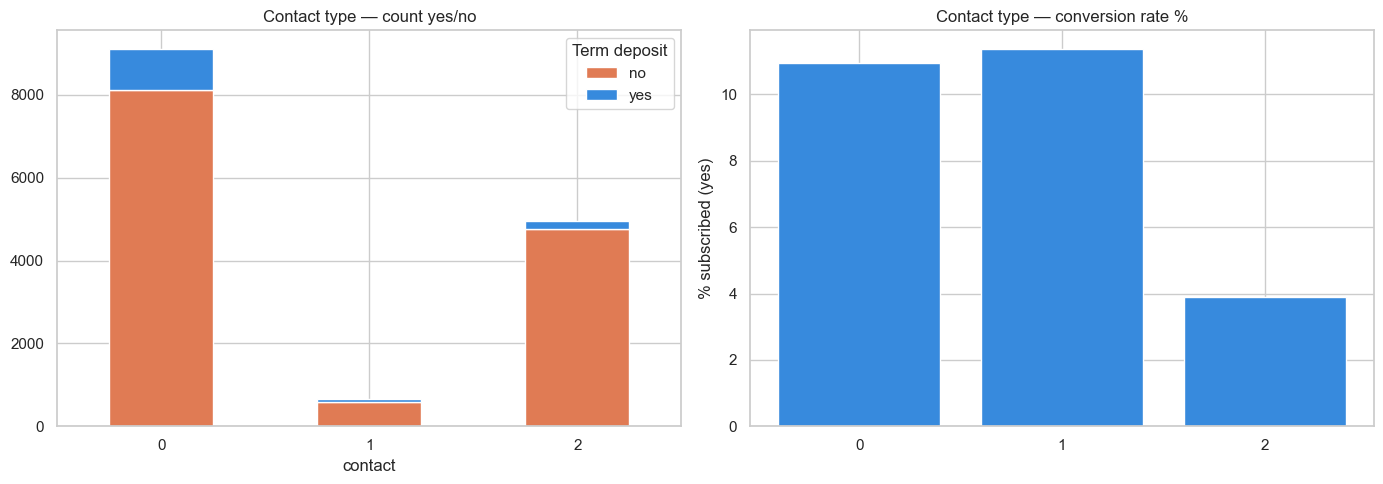

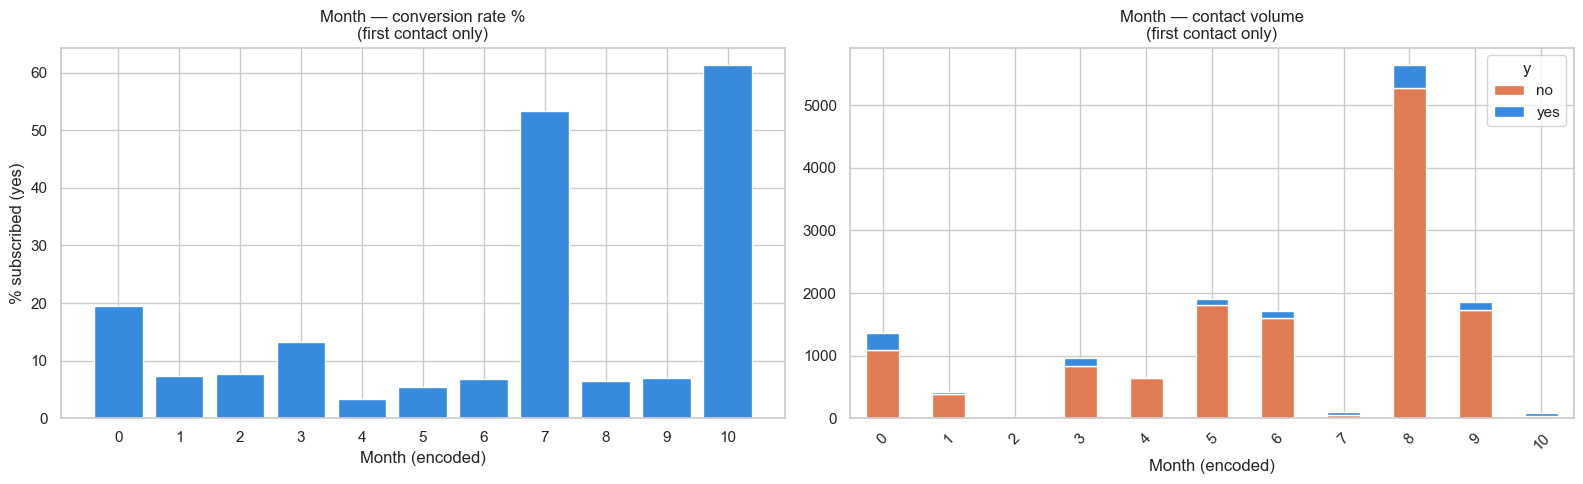

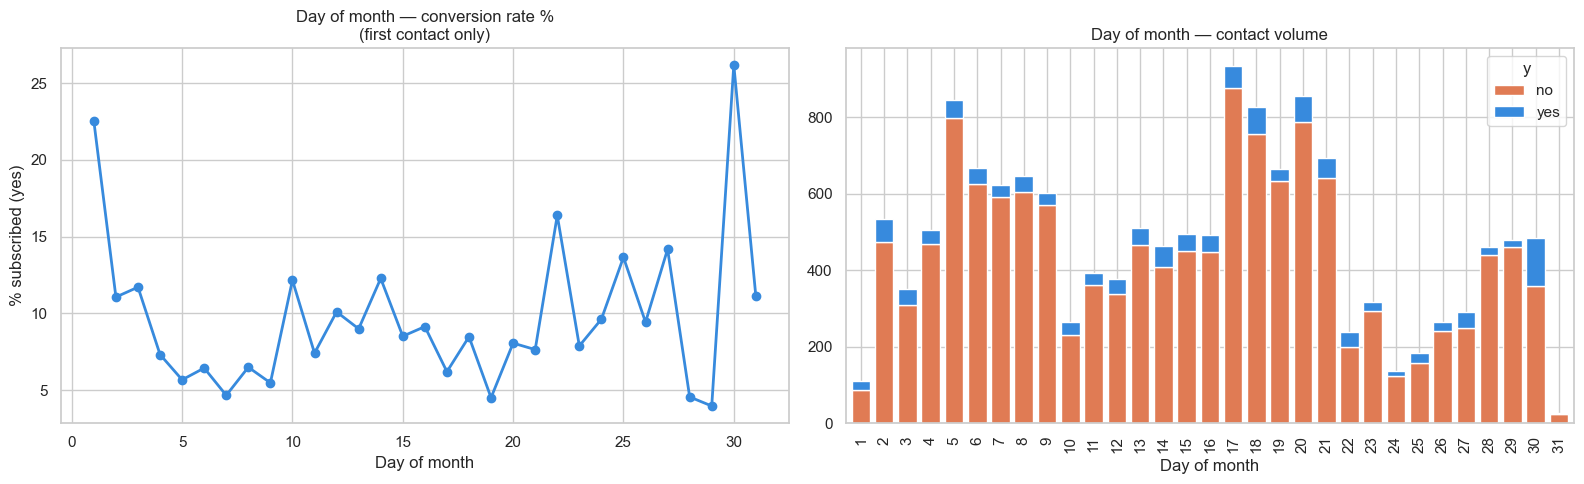

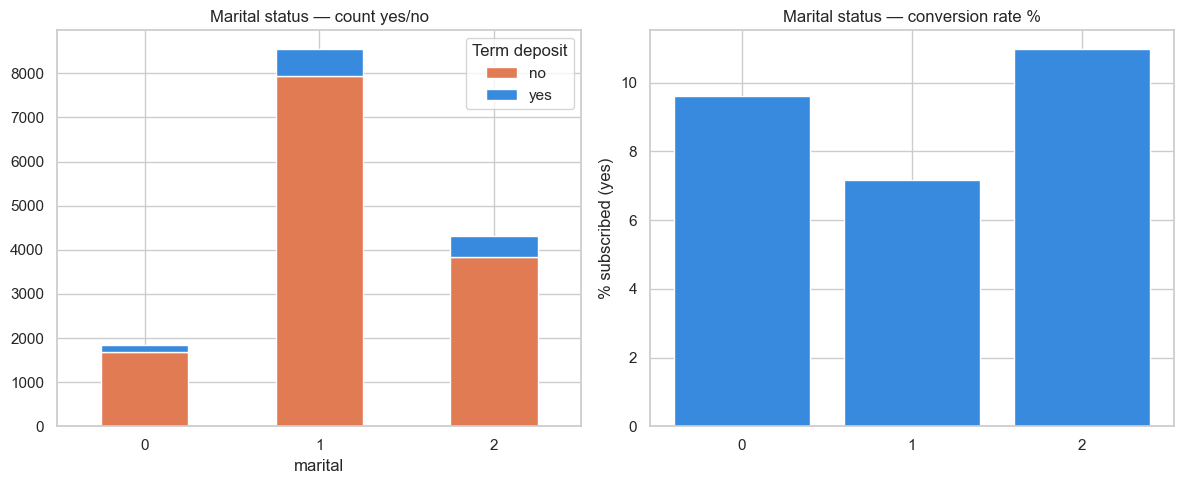


   SECTION 2 — SHAP ANALYSIS
   which features relate most to term deposit decision

SHAP aligned ✓  shape: (1000, 13)


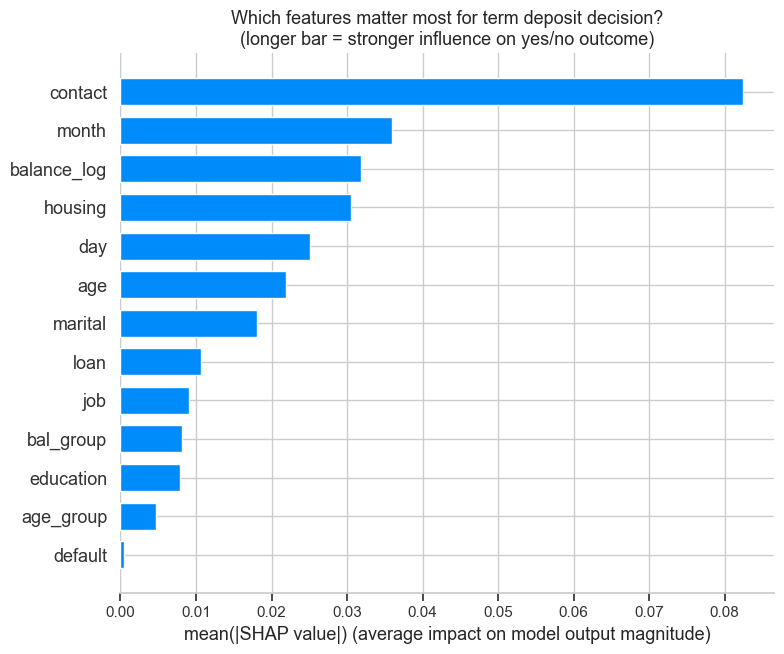

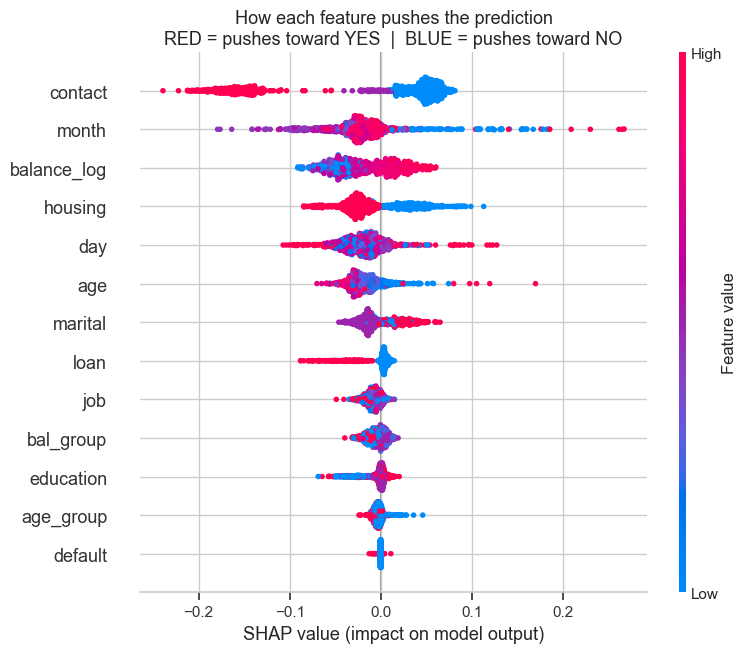


   SHAP RANKING — DEMOGRAPHIC vs CALL HISTORY
    feature  mean_abs_shap        group
    contact       0.082408 call_history
      month       0.035998 call_history
balance_log       0.031817  demographic
    housing       0.030497  demographic
        day       0.025071 call_history
        age       0.021923  demographic
    marital       0.018049  demographic
       loan       0.010601  demographic
        job       0.009041  demographic
  bal_group       0.008112  demographic
  education       0.007853  demographic
  age_group       0.004697  demographic
    default       0.000410  demographic

   GROUP TOTAL SHAP IMPACT
  Demographic  : 0.1430
  Call history : 0.1435


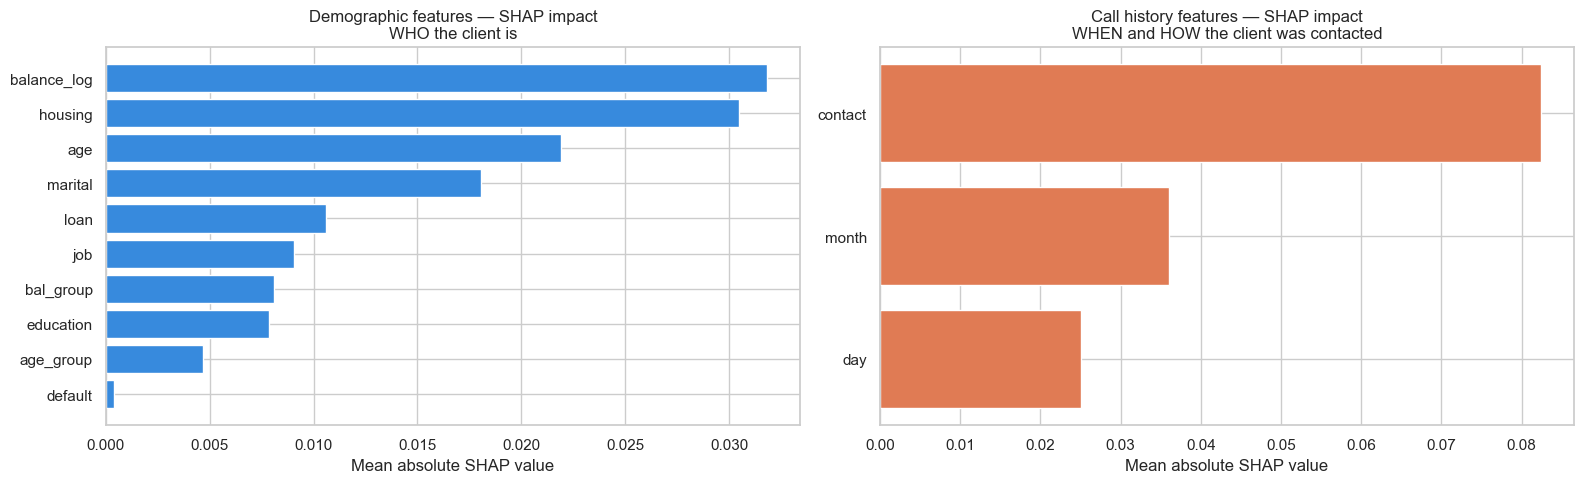


Top 3 features by SHAP impact: ['contact', 'month', 'balance_log']


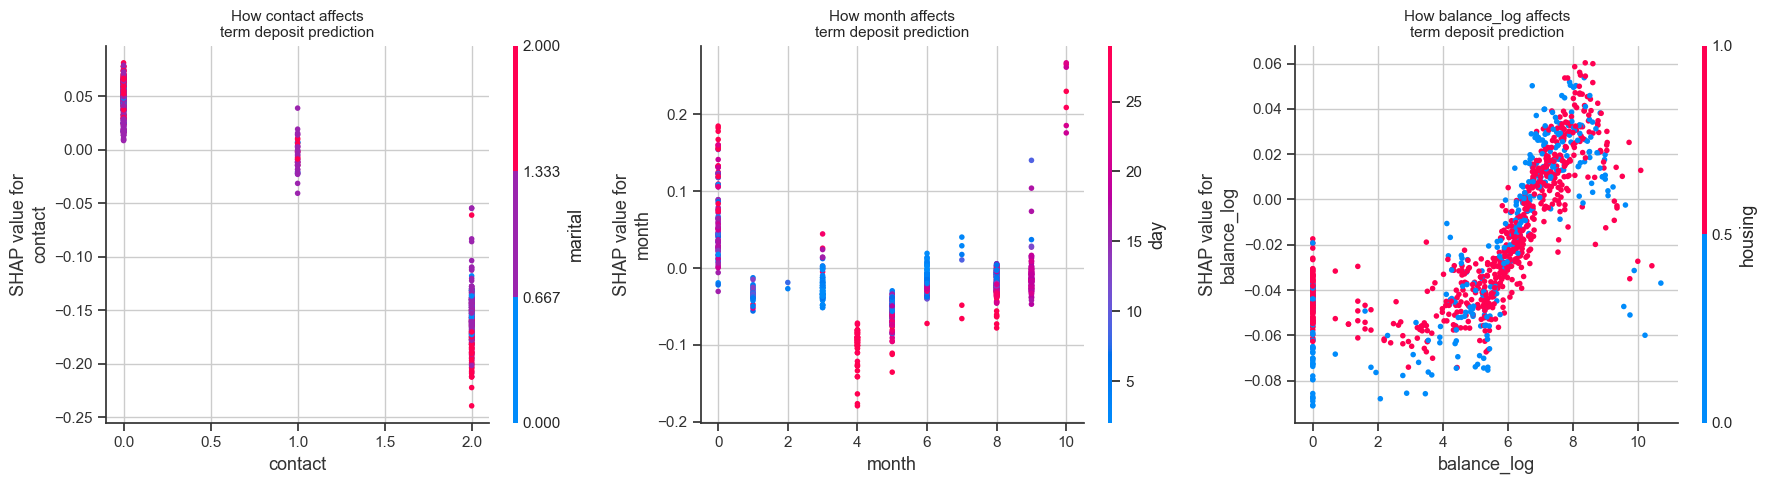


   PLAIN ENGLISH SHAP SUMMARY
   (for non-technical stakeholders)
  📅 WHEN  contact         █████████████████████████████████████████ 0.0824
  📅 WHEN  month           █████████████████ 0.0360
  👤 WHO  balance_log     ███████████████ 0.0318
  👤 WHO  housing         ███████████████ 0.0305
  📅 WHEN  day             ████████████ 0.0251
  👤 WHO  age             ██████████ 0.0219
  👤 WHO  marital         █████████ 0.0180
  👤 WHO  loan            █████ 0.0106
  👤 WHO  job             ████ 0.0090
  👤 WHO  bal_group       ████ 0.0081
  👤 WHO  education       ███ 0.0079
  👤 WHO  age_group       ██ 0.0047
  👤 WHO  default          0.0004

  HOW TO READ THIS:
  👤 WHO  = about the client's personal profile
  📅 WHEN = about when and how the call was made
  Longer bar = stronger influence on yes/no decision


In [31]:
from sklearn.preprocessing import LabelEncoder
import shap
import numpy as np

# ── 1. filter first contact only ────────────────────────────────────
layer1_df = eda_df[eda_df['campaign'] == 1].copy()

print(f"Total dataset      : {len(eda_df)} rows")
print(f"Layer 1 (campaign==1): {len(layer1_df)} rows")
print(f"Removed            : {len(eda_df) - len(layer1_df)} rows")

# ── 2. drop duration and campaign cols ──────────────────────────────
drop_cols = ['duration', 'campaign', 'campaign_log',
             'dur_group', 'duration_log', 'duration_sqrt',
             'duration_capped', 'engagement', 'engagement_bin',
             'engagement_enc']

layer1_df = layer1_df.drop(
    columns=[c for c in drop_cols if c in layer1_df.columns])

print(f"\nColumns after drop: {list(layer1_df.columns)}")

# ── 3. define feature lists ──────────────────────────────────────────
# clearly separated so non-technical stakeholders
# can see which group each feature belongs to

DEMOGRAPHIC_COLS = [
    'age',          # numeric — client age
    'age_group',    # binned age group
    'job',          # occupation
    'marital',      # marital status
    'education',    # education level
    'default',      # has credit default
    'balance_log',  # log of yearly balance
    'bal_group',    # balance band
    'housing',      # has housing loan
    'loan'          # has personal loan
]

CALL_HISTORY_COLS = [
    'month',        # last contact month
    'day',          # last contact day of month
    'contact'       # contact type (cellular/telephone/unknown)
]

ALL_FEATURES = DEMOGRAPHIC_COLS + CALL_HISTORY_COLS

print(f"\nDemographic features  : {DEMOGRAPHIC_COLS}")
print(f"Call history features : {CALL_HISTORY_COLS}")
print(f"Total features        : {len(ALL_FEATURES)}")

# ── 4. encode categoricals ───────────────────────────────────────────
cat_cols = ['job', 'marital', 'education', 'default',
            'housing', 'loan', 'age_group', 'bal_group',
            'contact', 'month']

le = LabelEncoder()
for col in cat_cols:
    layer1_df[col] = le.fit_transform(layer1_df[col].astype(str))

layer1_df['y_enc'] = (layer1_df['y'] == 'yes').astype(int)

print(f"\nTarget distribution (first contact only):")
print(f"  no  : {(layer1_df['y_enc']==0).sum()} "
      f"({(layer1_df['y_enc']==0).mean()*100:.1f}%)")
print(f"  yes : {(layer1_df['y_enc']==1).sum()} "
      f"({(layer1_df['y_enc']==1).mean()*100:.1f}%)")

# ════════════════════════════════════════════════════════════════════
# SECTION 1 — FULL EDA
# ════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("   SECTION 1 — FULL EDA (Layer 1, no duration)")
print("=" * 60)

COLORS = {'no': '#e07b54', 'yes': '#378add'}

# helper — conversion rate plot
def conv_rate_plot(col, ax, order=None, title=None, rotate=0):
    conv = (layer1_df.groupby(col)['y']
                .apply(lambda x: (x == 'yes').mean() * 100)
                .reset_index(name='pct_yes'))
    if order is not None:
        conv = conv.set_index(col).reindex(order).reset_index()
    ax.bar(conv[col].astype(str), conv['pct_yes'],
           color='#378add', edgecolor='white')
    ax.set_title(title or f'{col} — conversion rate %')
    ax.set_ylabel('% subscribed (yes)')
    ax.tick_params(axis='x', rotation=rotate)

# helper — stacked count plot
def stacked_count_plot(col, ax, order=None, title=None, rotate=0):
    counts = pd.crosstab(layer1_df[col], layer1_df['y'])
    if 'no' in counts.columns and 'yes' in counts.columns:
        counts = counts[['no', 'yes']]
    if order is not None:
        counts = counts.reindex(order)
    counts.plot(kind='bar', stacked=True, ax=ax,
                color=[COLORS['no'], COLORS['yes']],
                edgecolor='white')
    ax.set_title(title or f'{col} — count yes/no')
    ax.tick_params(axis='x', rotation=rotate)
    ax.legend(title='Term deposit')

# ── EDA 1 : target distribution ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

counts = layer1_df['y'].value_counts()
axes[0].bar(counts.index, counts.values,
            color=[COLORS['no'], COLORS['yes']],
            edgecolor='white')
axes[0].set_title('Target distribution\n(first contact only)')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontweight='bold')

axes[1].pie(counts.values,
            labels=[f'No ({counts["no"]})',
                    f'Yes ({counts["yes"]})'],
            colors=[COLORS['no'], COLORS['yes']],
            autopct='%1.1f%%', startangle=90)
axes[1].set_title('Target split %\n(first contact only)')
plt.tight_layout()
plt.show()

# ── EDA 2 : age ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for label in ['no', 'yes']:
    layer1_df[layer1_df['y'] == label]['age'].plot.kde(
        ax=axes[0], label=label,
        linewidth=2, color=COLORS[label])
axes[0].set_title('Age density — yes vs no\n(first contact)')
axes[0].set_xlabel('Age')
axes[0].legend(title='Term deposit')

import seaborn as sns
sns.boxplot(data=layer1_df, x='y', y='age', ax=axes[1],
            order=['no', 'yes'], palette=COLORS)
axes[1].set_title('Age spread — yes vs no')
axes[1].set_xlabel('Term deposit')

age_order = ['18-25', '26-40', '41-65', '65+']
conv_rate_plot('age_group', axes[2],
               title='Age group — conversion rate %',
               rotate=0)
plt.tight_layout()
plt.show()

# ── EDA 3 : education ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stacked_count_plot('education', axes[0],
                   title='Education — count yes/no')
conv_rate_plot('education', axes[1],
               title='Education — conversion rate %')
plt.tight_layout()
plt.show()

# ── EDA 4 : job ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
stacked_count_plot('job', axes[0],
                   title='Job — count yes/no', rotate=45)
conv_rate_plot('job', axes[1],
               title='Job — conversion rate %', rotate=45)
plt.tight_layout()
plt.show()

# ── EDA 5 : balance ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

bal_clip = layer1_df[
    layer1_df['balance_log'].between(0, 12)]
for label in ['no', 'yes']:
    bal_clip[bal_clip['y'] == label]['balance_log'].plot.kde(
        ax=axes[0], label=label,
        linewidth=2, color=COLORS[label])
axes[0].set_title('Balance (log) density — yes vs no')
axes[0].set_xlabel('log(balance + 1)')
axes[0].legend(title='Term deposit')

sns.boxplot(data=layer1_df, x='y', y='balance_log',
            ax=axes[1], order=['no', 'yes'], palette=COLORS)
axes[1].set_title('Balance (log) spread — yes vs no')
axes[1].set_xlabel('Term deposit')

conv_rate_plot('bal_group', axes[2],
               title='Balance band — conversion rate %')
plt.tight_layout()
plt.show()

# ── EDA 6 : housing + loan ───────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
for i, col in enumerate(['housing', 'loan']):
    stacked_count_plot(col, axes[i][0],
                       title=f'{col.title()} loan — count')
    conv_rate_plot(col, axes[i][1],
                   title=f'{col.title()} loan — conversion %')
plt.tight_layout()
plt.show()

# ── EDA 7 : default ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stacked_count_plot('default', axes[0],
                   title='Credit default — count yes/no')
conv_rate_plot('default', axes[1],
               title='Credit default — conversion rate %')
plt.tight_layout()
plt.show()

# ── EDA 8 : contact type ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
stacked_count_plot('contact', axes[0],
                   title='Contact type — count yes/no')
conv_rate_plot('contact', axes[1],
               title='Contact type — conversion rate %')
plt.tight_layout()
plt.show()

# ── EDA 9 : month ────────────────────────────────────────────────────
month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

month_conv = (layer1_df.groupby('month')['y']
                  .apply(lambda x: (x == 'yes').mean() * 100)
                  .reset_index(name='pct_yes'))
axes[0].bar(month_conv['month'].astype(str),
            month_conv['pct_yes'],
            color='#378add', edgecolor='white')
axes[0].set_title('Month — conversion rate %\n(first contact only)')
axes[0].set_xlabel('Month (encoded)')
axes[0].set_ylabel('% subscribed (yes)')

month_vol = (layer1_df.groupby(['month', 'y'])
                 .size().unstack(fill_value=0))
month_vol.plot(kind='bar', stacked=True, ax=axes[1],
               color=[COLORS['no'], COLORS['yes']],
               edgecolor='white')
axes[1].set_title('Month — contact volume\n(first contact only)')
axes[1].set_xlabel('Month (encoded)')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# ── EDA 10 : day ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

day_conv = (layer1_df.groupby('day')['y']
                .apply(lambda x: (x == 'yes').mean() * 100)
                .reset_index(name='pct_yes'))
axes[0].plot(day_conv['day'], day_conv['pct_yes'],
             marker='o', color='#378add', linewidth=2)
axes[0].set_title('Day of month — conversion rate %\n(first contact only)')
axes[0].set_xlabel('Day of month')
axes[0].set_ylabel('% subscribed (yes)')

day_vol = layer1_df.groupby(['day', 'y']).size().unstack(fill_value=0)
day_vol.plot(kind='bar', stacked=True, ax=axes[1],
             color=[COLORS['no'], COLORS['yes']],
             edgecolor='white', width=0.8)
axes[1].set_title('Day of month — contact volume')
axes[1].set_xlabel('Day of month')
axes[1].tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.show()

# ── EDA 11 : marital ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
stacked_count_plot('marital', axes[0],
                   title='Marital status — count yes/no')
conv_rate_plot('marital', axes[1],
               title='Marital status — conversion rate %')
plt.tight_layout()
plt.show()

# ════════════════════════════════════════════════════════════════════
# SECTION 2 — SHAP ANALYSIS (before model training)
# non-technical explanation of which features relate to yes/no
# ════════════════════════════════════════════════════════════════════
print("\n" + "=" * 60)
print("   SECTION 2 — SHAP ANALYSIS")
print("   which features relate most to term deposit decision")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier

X_shap = layer1_df[ALL_FEATURES]
y_shap = layer1_df['y_enc']

# lightweight RF for SHAP — exploratory only
rf_shap = RandomForestClassifier(
    n_estimators=100,
    max_depth=10,
    class_weight='balanced',
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf_shap.fit(X_shap, y_shap)

# sample for speed
X_shap_sample = X_shap.sample(1000, random_state=42).reset_index(drop=True)

explainer   = shap.TreeExplainer(rf_shap)
shap_vals   = explainer.shap_values(X_shap_sample)

# extract class 1 (yes) shap values safely
sv = shap_vals[1] if isinstance(shap_vals, list) else shap_vals
if isinstance(shap_vals, list):
    # older shap — list of one array per class
    sv = shap_vals[1]
elif shap_vals.ndim == 3:
    # newer shap — 3D array (samples, features, classes)
    sv = shap_vals[:, :, 1]
else:
    # 2D array — already the positive class
    sv = shap_vals

# verify alignment
assert sv.shape == X_shap_sample.shape, \
    f"Shape mismatch: SHAP {sv.shape} vs X {X_shap_sample.shape}"
print(f"\nSHAP aligned ✓  shape: {sv.shape}")

# ── SHAP 1 : overall importance bar ─────────────────────────────────
plt.figure(figsize=(10, 6))
shap.summary_plot(
    sv, X_shap_sample,
    feature_names=ALL_FEATURES,
    plot_type='bar', show=False)
plt.title('Which features matter most for term deposit decision?\n'
          '(longer bar = stronger influence on yes/no outcome)',
          fontsize=13)
plt.tight_layout()
plt.show()

# ── SHAP 2 : beeswarm — direction ───────────────────────────────────
plt.figure(figsize=(10, 8))
shap.summary_plot(
    sv, X_shap_sample,
    feature_names=ALL_FEATURES,
    show=False)
plt.title('How each feature pushes the prediction\n'
          'RED = pushes toward YES  |  BLUE = pushes toward NO',
          fontsize=13)
plt.tight_layout()
plt.show()

# ── SHAP 3 : demographic group vs call history group ─────────────────
mean_shap = np.abs(sv).mean(axis=0)
shap_df   = pd.DataFrame({
    'feature'        : ALL_FEATURES,
    'mean_abs_shap'  : mean_shap,
    'group'          : (['demographic'] * len(DEMOGRAPHIC_COLS) +
                        ['call_history'] * len(CALL_HISTORY_COLS))
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print("\n" + "=" * 60)
print("   SHAP RANKING — DEMOGRAPHIC vs CALL HISTORY")
print("=" * 60)
print(shap_df.to_string(index=False))

# group total impact
group_impact = shap_df.groupby('group')['mean_abs_shap'].sum()
print("\n" + "=" * 60)
print("   GROUP TOTAL SHAP IMPACT")
print("=" * 60)
print(f"  Demographic  : {group_impact.get('demographic', 0):.4f}")
print(f"  Call history : {group_impact.get('call_history', 0):.4f}")
print("=" * 60)

# ── SHAP 4 : grouped bar — demographic vs call history ───────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

demo_shap = shap_df[shap_df['group'] == 'demographic'].sort_values(
    'mean_abs_shap', ascending=True)
call_shap = shap_df[shap_df['group'] == 'call_history'].sort_values(
    'mean_abs_shap', ascending=True)

axes[0].barh(demo_shap['feature'],
             demo_shap['mean_abs_shap'],
             color='#378add', edgecolor='white')
axes[0].set_title('Demographic features — SHAP impact\n'
                  'WHO the client is')
axes[0].set_xlabel('Mean absolute SHAP value')

axes[1].barh(call_shap['feature'],
             call_shap['mean_abs_shap'],
             color='#e07b54', edgecolor='white')
axes[1].set_title('Call history features — SHAP impact\n'
                  'WHEN and HOW the client was contacted')
axes[1].set_xlabel('Mean absolute SHAP value')

plt.tight_layout()
plt.show()

# ── SHAP 5 : dependence plots for top 3 features ─────────────────────
top3 = shap_df.head(3)['feature'].tolist()
print(f"\nTop 3 features by SHAP impact: {top3}")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, feat in enumerate(top3):
    shap.dependence_plot(
        feat, sv, X_shap_sample,
        feature_names=ALL_FEATURES,
        ax=axes[i], show=False)
    axes[i].set_title(f'How {feat} affects\nterm deposit prediction',
                      fontsize=11)
plt.tight_layout()
plt.show()

# ── SHAP 6 : non-technical plain english summary ─────────────────────
print("\n" + "=" * 60)
print("   PLAIN ENGLISH SHAP SUMMARY")
print("   (for non-technical stakeholders)")
print("=" * 60)
for _, row in shap_df.iterrows():
    bar = "█" * int(row['mean_abs_shap'] * 500)
    tag = "👤 WHO" if row['group'] == 'demographic' else "📅 WHEN"
    print(f"  {tag}  {row['feature']:<15} {bar} {row['mean_abs_shap']:.4f}")
print("=" * 60)
print("\n  HOW TO READ THIS:")
print("  👤 WHO  = about the client's personal profile")
print("  📅 WHEN = about when and how the call was made")
print("  Longer bar = stronger influence on yes/no decision")
print("=" * 60)

# RandomForest Model 

   LAYER 1 — FIRST CALL TERM DEPOSIT PREDICTION
   no duration | no SMOTE | class_weight balanced

Demographic features  (10) : ['age', 'age_group', 'job', 'marital', 'education', 'default', 'balance_log', 'bal_group', 'housing', 'loan']
Call history features (3) : ['month', 'day', 'contact']

Total Layer 1 rows : 14718
Class distribution :
  no  : 13454 (91.4%)
  yes : 1264 (8.6%)

Train : 11774 rows
Test  : 2944 rows
Train yes : 1011 (8.6%)
Test  yes : 253  (8.6%)

   RFE FEATURE SELECTION
    feature  selected  rank
  age_group      True     1
  bal_group      True     1
balance_log      True     1
    contact      True     1
        day      True     1
      month      True     1
       loan      True     1
    housing      True     1
        age     False     2
    marital     False     3
  education     False     4
    default     False     5
        job     False     6

RFE selected 8 features:
  ['age_group', 'balance_log', 'bal_group', 'housing', 'loan', 'month', 'day', 'conta

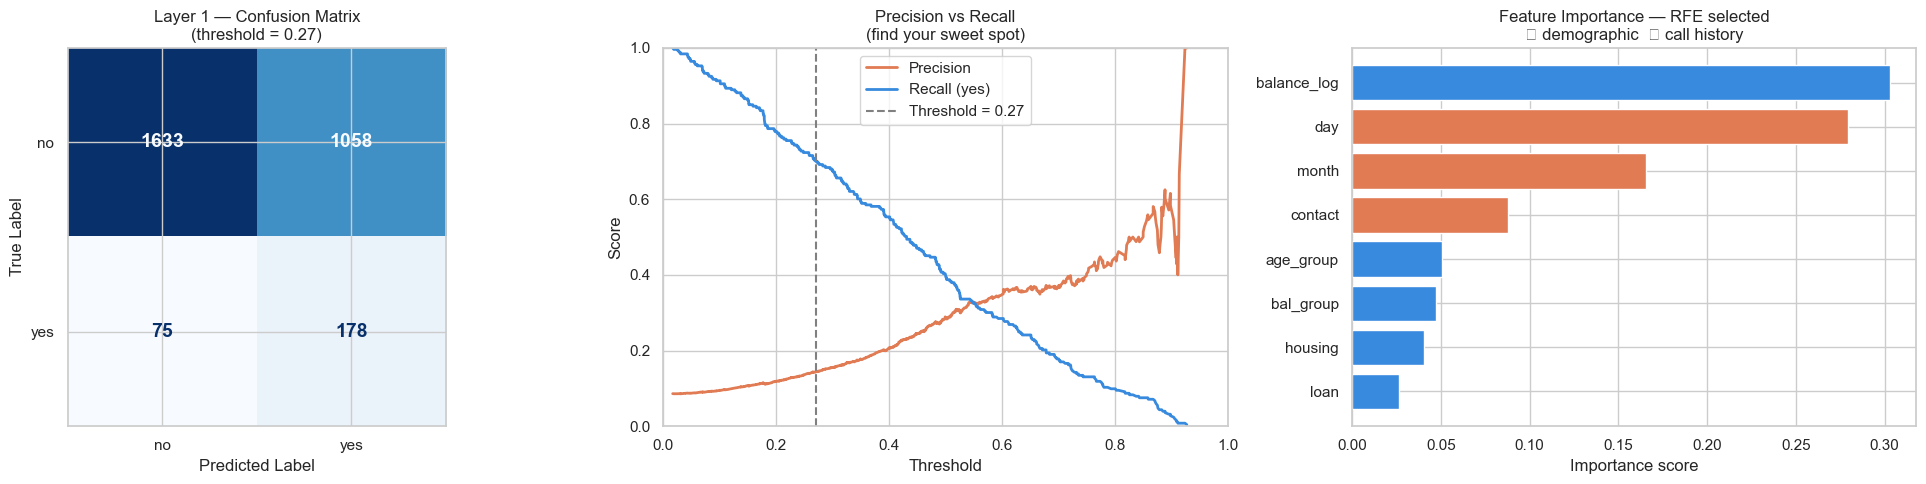


   FEATURE COMPARISON — RFE rank vs RF importance
  Feature         Group           RFE rank  RF Importance  Selected
-----------------------------------------------------------------
  age_group       demographic            1         0.0508         ✓
  bal_group       demographic            1         0.0470         ✓
  balance_log     demographic            1         0.3028         ✓
  contact         call_history           1         0.0876         ✓
  day             call_history           1         0.2792         ✓
  month           call_history           1         0.1655         ✓
  loan            demographic            1         0.0266         ✓
  housing         demographic            1         0.0404         ✓
  age             demographic            2         0.0000         ✗
  marital         demographic            3         0.0000         ✗
  education       demographic            4         0.0000         ✗
  default         demographic            5         0.0000         ✗

In [32]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.feature_selection import RFE
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             confusion_matrix, precision_recall_curve)
import numpy as np

# ── 1. define features based on SHAP recommendations ────────────────
DEMOGRAPHIC_COLS = [
    'age', 'age_group', 'job', 'marital', 'education',
    'default', 'balance_log', 'bal_group', 'housing', 'loan'
]

CALL_HISTORY_COLS = ['month', 'day', 'contact']

ALL_FEATURES = DEMOGRAPHIC_COLS + CALL_HISTORY_COLS

print("=" * 55)
print("   LAYER 1 — FIRST CALL TERM DEPOSIT PREDICTION")
print("   no duration | no SMOTE | class_weight balanced")
print("=" * 55)
print(f"\nDemographic features  ({len(DEMOGRAPHIC_COLS)}) : {DEMOGRAPHIC_COLS}")
print(f"Call history features ({len(CALL_HISTORY_COLS)}) : {CALL_HISTORY_COLS}")

# ── 2. prepare data ──────────────────────────────────────────────────
X = layer1_df[ALL_FEATURES]
y = layer1_df['y_enc']

print(f"\nTotal Layer 1 rows : {len(X)}")
print(f"Class distribution :")
print(f"  no  : {(y==0).sum()} ({(y==0).mean()*100:.1f}%)")
print(f"  yes : {(y==1).sum()} ({(y==1).mean()*100:.1f}%)")

# ── 3. train test split ──────────────────────────────────────────────
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain : {X_train_raw.shape[0]} rows")
print(f"Test  : {X_test_raw.shape[0]} rows")
print(f"Train yes : {y_train.sum()} ({y_train.mean()*100:.1f}%)")
print(f"Test  yes : {y_test.sum()}  ({y_test.mean()*100:.1f}%)")

# ── 4. scale for RFE only ────────────────────────────────────────────
# RF does not need scaling but LogisticRegression for RFE does
from sklearn.preprocessing import StandardScaler

scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_raw)
X_test_sc  = scaler.transform(X_test_raw)

# ── 5. RFE — logistic regression to rank features ────────────────────
# RF natively has feature_importances_ but LR gives cleaner
# linear ranking for RFE — faster and less biased for selection

print("\n" + "=" * 55)
print("   RFE FEATURE SELECTION")
print("=" * 55)

N_FEATURES = 8   # based on SHAP — keep features with impact > 0.01

rfe_estimator = LogisticRegression(
    class_weight='balanced',
    max_iter=1000,
    random_state=42
)

rfe = RFE(
    estimator=rfe_estimator,
    n_features_to_select=N_FEATURES,
    step=1
)
rfe.fit(X_train_sc, y_train)

# RFE results table
rfe_df = pd.DataFrame({
    'feature'  : ALL_FEATURES,
    'selected' : rfe.support_,
    'rank'     : rfe.ranking_
}).sort_values('rank')

print(rfe_df.to_string(index=False))

selected_features = [f for f, s in zip(ALL_FEATURES, rfe.support_) if s]
print(f"\nRFE selected {N_FEATURES} features:")
print(f"  {selected_features}")

# check overlap with SHAP recommendations
shap_recommended = ['contact', 'month', 'day', 'balance_log',
                    'housing', 'age', 'marital', 'loan']
overlap = set(selected_features) & set(shap_recommended)
print(f"\nOverlap with SHAP top features : {len(overlap)}/8")
print(f"  Matching : {sorted(overlap)}")

# ── 6. filter to RFE selected features — raw unscaled for RF ─────────
X_train_sel = X_train_raw[selected_features].values
X_test_sel  = X_test_raw[selected_features].values

# ── 7. train Random Forest ───────────────────────────────────────────
print("\n" + "=" * 55)
print("   RANDOM FOREST — LAYER 1 MODEL")
print("=" * 55)

rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',    # handles imbalance natively
    max_depth=None,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train_sel, y_train)
print("Model trained ✓")

# ── 8. threshold tuning ──────────────────────────────────────────────
y_prob = rf.predict_proba(X_test_sel)[:, 1]

# find best threshold by maximising yes recall
# while keeping precision above a minimum floor
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(
    y_test, y_prob)

# find threshold where recall yes >= 70% with best precision
best_threshold = 0.3   # default starting point
best_f1        = 0

for thresh in np.arange(0.1, 0.6, 0.01):
    preds    = (y_prob >= thresh).astype(int)
    cm_t     = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
        if (tp_t + fn_t) > 0 and (tp_t + fp_t) > 0:
            rec  = tp_t / (tp_t + fn_t)
            prec = tp_t / (tp_t + fp_t)
            f1   = 2 * prec * rec / (prec + rec) if (prec + rec) > 0 else 0
            # prioritise recall >= 0.70 then pick best f1
            if rec >= 0.70 and f1 > best_f1:
                best_f1        = f1
                best_threshold = thresh

print(f"\nAuto-selected threshold : {best_threshold:.2f}")
print(f"(recall YES >= 70% with best F1)")

THRESHOLD    = best_threshold
y_pred_tuned = (y_prob >= THRESHOLD).astype(int)

# ── 9. classification report ────────────────────────────────────────
print(f"\nClassification Report (threshold = {THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_tuned,
      target_names=['no', 'yes']))

# ── 10. detailed confusion matrix breakdown ──────────────────────────
cm             = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

no_precision  = tn / (tn + fn)  if (tn + fn) > 0 else 0
no_recall     = tn / (tn + fp)  if (tn + fp) > 0 else 0
no_f1         = (2 * no_precision * no_recall /
                 (no_precision + no_recall)
                 if (no_precision + no_recall) > 0 else 0)

yes_precision = tp / (tp + fp)  if (tp + fp) > 0 else 0
yes_recall    = tp / (tp + fn)  if (tp + fn) > 0 else 0
yes_f1        = (2 * yes_precision * yes_recall /
                 (yes_precision + yes_recall)
                 if (yes_precision + yes_recall) > 0 else 0)

accuracy = (tn + tp) / (tn + fp + fn + tp)

print("=" * 60)
print("            CONFUSION MATRIX BREAKDOWN")
print("=" * 60)
print(f"  True  Negative (TN) : {tn:>6}  — correctly predicted NO")
print(f"  False Positive (FP) : {fp:>6}  — said YES but actually NO")
print(f"  False Negative (FN) : {fn:>6}  — said NO  but actually YES  ← minimise")
print(f"  True  Positive (TP) : {tp:>6}  — correctly predicted YES")
print("=" * 60)
print(f"  Overall Accuracy    : {accuracy*100:.1f}%")
print("=" * 60)

print("\n" + "=" * 60)
print("       FULL CLASSIFICATION REPORT BY CLASS")
print("=" * 60)
print(f"  {'Metric':<18} {'NO (class 0)':>15} {'YES (class 1)':>15}")
print("-" * 60)
print(f"  {'Precision':<18} {no_precision*100:>14.1f}% {yes_precision*100:>14.1f}%")
print(f"  {'Recall':<18} {no_recall*100:>14.1f}% {yes_recall*100:>14.1f}%")
print(f"  {'F1 Score':<18} {no_f1*100:>14.1f}% {yes_f1*100:>14.1f}%")
print(f"  {'Support':<18} {tn+fp:>15} {tp+fn:>15}")
print("=" * 60)
print(f"\n  ► Recall YES  : {yes_recall*100:.1f}%  — real YES clients caught")
print(f"  ► Recall NO   : {no_recall*100:.1f}%  — real NO  clients caught")
print(f"  ► FN (missed) : {fn}     — YES clients model missed")
print(f"  ► FP (noise)  : {fp}    — NO clients flagged as YES")
print("=" * 60)

# ── 11. plots ────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Layer 1 — Confusion Matrix\n'
                  f'(threshold = {THRESHOLD:.2f})')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')
for text in axes[0].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# precision recall curve
axes[1].plot(thresholds_arr, precision_arr[:-1],
             label='Precision', color='#e07b54', linewidth=2)
axes[1].plot(thresholds_arr, recall_arr[:-1],
             label='Recall (yes)', color='#378add', linewidth=2)
axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--',
                label=f'Threshold = {THRESHOLD:.2f}')
axes[1].set_title('Precision vs Recall\n(find your sweet spot)')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

# feature importance — selected features only
imp_df = pd.DataFrame({
    'feature'   : selected_features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

colors = ['#378add' if f in DEMOGRAPHIC_COLS
          else '#e07b54' for f in imp_df['feature']]

axes[2].barh(imp_df['feature'], imp_df['importance'],
             color=colors, edgecolor='white')
axes[2].set_title('Feature Importance — RFE selected\n'
                  '🔵 demographic  🟠 call history')
axes[2].set_xlabel('Importance score')

plt.tight_layout()
plt.show()

# ── 12. RFE rank + SHAP + RF importance comparison table ─────────────
print("\n" + "=" * 65)
print("   FEATURE COMPARISON — RFE rank vs RF importance")
print("=" * 65)
print(f"  {'Feature':<15} {'Group':<14} {'RFE rank':>9} "
      f"{'RF Importance':>14} {'Selected':>9}")
print("-" * 65)

imp_lookup = dict(zip(selected_features, rf.feature_importances_))
for _, row in rfe_df.iterrows():
    imp_val = imp_lookup.get(row['feature'], 0.0)
    grp     = ('demographic'
               if row['feature'] in DEMOGRAPHIC_COLS
               else 'call_history')
    sel_tag = '✓' if row['selected'] else '✗'
    print(f"  {row['feature']:<15} {grp:<14} "
          f"{row['rank']:>9} {imp_val:>14.4f} {sel_tag:>9}")
print("=" * 65)

   LAYER 1 — MANUAL FEATURE EXPERIMENT
   Active set : SET 3 — call history only

Features in use (6) : ['contact', 'month', 'balance_log', 'housing', 'day', 'age']

Train : 11774 rows (yes: 1011, no: 10763)
Test  : 2944 rows (yes: 253,  no: 2691)

Model trained ✓
Auto threshold : 0.24

Classification Report (threshold = 0.24):
              precision    recall  f1-score   support

          no       0.96      0.63      0.76      2691
         yes       0.15      0.71      0.25       253

    accuracy                           0.64      2944
   macro avg       0.56      0.67      0.51      2944
weighted avg       0.89      0.64      0.72      2944

            CONFUSION MATRIX BREAKDOWN
  True  Negative (TN) :   1707  — correctly predicted NO
  False Positive (FP) :    984  — said YES but actually NO
  False Negative (FN) :     73  — said NO but actually YES  ← minimise
  True  Positive (TP) :    180  — correctly predicted YES
  Overall Accuracy    : 64.1%

       FULL CLASSIFICATION R

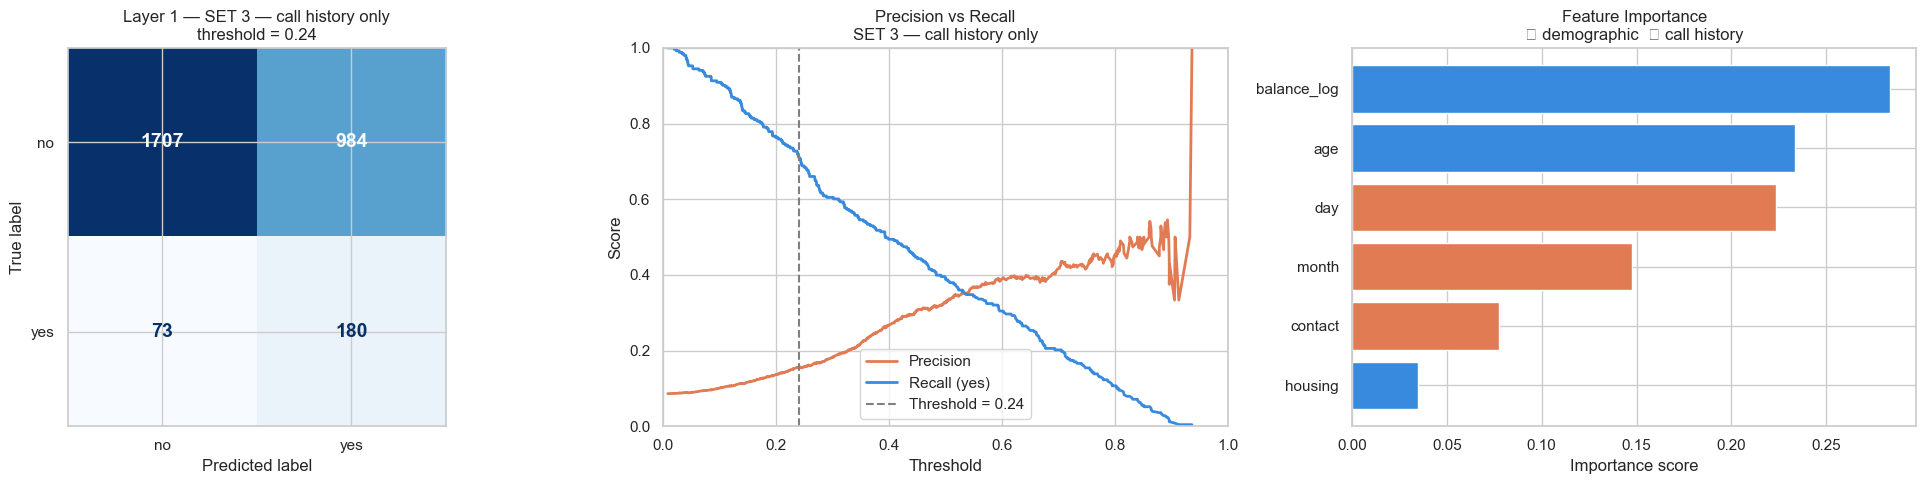


   EXPERIMENT TRACKER — run each set and fill in results
  Set                                  Recall YES  Prec YES   F1 YES    FN  Threshold
----------------------------------------------------------------------
  SET_1 — all features                          ?         ?        ?     ?          ?
  SET_2 — drop redundant (CURRENT)          71.1%     15.5%    25.4%    73       0.24
  SET_3 — call history only                     ?         ?        ?     ?          ?
  SET_4 — demographics only                     ?         ?        ?     ?          ?
  SET_5 — SHAP top 8                            ?         ?        ?     ?          ?
  SET_6 — strongest 6 only                      ?         ?        ?     ?          ?

  ► Change ALL_FEATURES = SET_X to run each experiment
  ► Fill in the ? values as you run each set
  ► Best set = highest recall YES with lowest FN


In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, ConfusionMatrixDisplay,
                             confusion_matrix, precision_recall_curve)
import numpy as np

# ── feature sets to experiment with ─────────────────────────────────
# start broad then narrow down manually
# comment/uncomment features to test combinations

DEMOGRAPHIC_COLS = [
    'age',           # ← try removing if age_group is present
    'age_group',     # ← try removing if age is present (redundant)
    'job',
    'marital',
    'education',
    'default',       # ← SHAP score 0.0004 — likely noise
    'balance_log',   # ← strong signal 0.0318
    'bal_group',     # ← redundant with balance_log — try removing
    'housing',       # ← decent signal 0.0305
    'loan'           # ← weak signal 0.0106
]

CALL_HISTORY_COLS = [
    'month',         # ← strong signal 0.0360
    'day',           # ← moderate signal 0.0251
    'contact'        # ← strongest single feature 0.0824
]

# ── experiment sets — swap ALL_FEATURES to test each ─────────────────

# SET 1 — everything (baseline)
SET_1_ALL = DEMOGRAPHIC_COLS + CALL_HISTORY_COLS

# SET 2 — drop redundant bins (age_group, bal_group, default)
SET_2_DROP_REDUNDANT = [
    'age', 'job', 'marital', 'education',
    'balance_log', 'housing', 'loan',
    'month', 'day', 'contact'
]

# SET 3 — call history only (pure timing signal)
SET_3_CALL_ONLY = [
    'month', 'day', 'contact'
]

# SET 4 — demographics only (pure profile signal)
SET_4_DEMO_ONLY = [
    'age', 'job', 'marital', 'education',
    'balance_log', 'housing', 'loan'
]

# SET 5 — SHAP top features only (above 0.01 threshold)
SET_5_SHAP_TOP = [
    'contact', 'month', 'balance_log',
    'housing', 'day', 'age', 'marital', 'loan'
]

# SET 6 — strongest signals only (above 0.02 shap threshold)
SET_6_STRONG_ONLY = [
    'contact', 'month', 'balance_log',
    'housing', 'day', 'age'
]

# ── CHANGE THIS LINE to switch between sets ──────────────────────────
ALL_FEATURES = SET_6_STRONG_ONLY  # ← swap set here
ACTIVE_SET   = "SET 6 - strongest signals only"

print("=" * 60)
print("   LAYER 1 — MANUAL FEATURE EXPERIMENT")
print(f"   Active set : {ACTIVE_SET}")
print("=" * 60)
print(f"\nFeatures in use ({len(ALL_FEATURES)}) : {ALL_FEATURES}")

# ── tag each feature for colour coding ──────────────────────────────
DEMO_BASE = ['age', 'age_group', 'job', 'marital', 'education',
             'default', 'balance_log', 'bal_group', 'housing', 'loan']
CALL_BASE = ['month', 'day', 'contact']

# ── prepare data ─────────────────────────────────────────────────────
X = layer1_df[ALL_FEATURES]
y = layer1_df['y_enc']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print(f"\nTrain : {X_train.shape[0]} rows "
      f"(yes: {y_train.sum()}, no: {(y_train==0).sum()})")
print(f"Test  : {X_test.shape[0]} rows "
      f"(yes: {y_test.sum()},  no: {(y_test==0).sum()})")

# ── train RF ─────────────────────────────────────────────────────────
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight='balanced',
    max_depth=None,
    min_samples_leaf=5,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
print("\nModel trained ✓")

# ── auto threshold selection ─────────────────────────────────────────
y_prob = rf.predict_proba(X_test)[:, 1]

precision_arr, recall_arr, thresholds_arr = precision_recall_curve(
    y_test, y_prob)

best_threshold = 0.3
best_f1        = 0

for thresh in np.arange(0.1, 0.6, 0.01):
    preds = (y_prob >= thresh).astype(int)
    cm_t  = confusion_matrix(y_test, preds)
    if cm_t.shape == (2, 2):
        tn_t, fp_t, fn_t, tp_t = cm_t.ravel()
        if (tp_t + fn_t) > 0 and (tp_t + fp_t) > 0:
            rec  = tp_t / (tp_t + fn_t)
            prec = tp_t / (tp_t + fp_t)
            f1   = (2 * prec * rec / (prec + rec)
                    if (prec + rec) > 0 else 0)
            if rec >= 0.70 and f1 > best_f1:
                best_f1        = f1
                best_threshold = thresh

print(f"Auto threshold : {best_threshold:.2f}")

THRESHOLD    = best_threshold
y_pred_tuned = (y_prob >= THRESHOLD).astype(int)

# ── classification report ─────────────────────────────────────────────
report = classification_report(
    y_test, y_pred_tuned,
    target_names=['no', 'yes'],
    output_dict=True)

print(f"\nClassification Report (threshold = {THRESHOLD:.2f}):")
print(classification_report(y_test, y_pred_tuned,
      target_names=['no', 'yes']))

# ── confusion matrix breakdown ───────────────────────────────────────
cm             = confusion_matrix(y_test, y_pred_tuned)
tn, fp, fn, tp = cm.ravel()

no_precision  = tn / (tn + fn)  if (tn + fn) > 0 else 0
no_recall     = tn / (tn + fp)  if (tn + fp) > 0 else 0
no_f1         = (2 * no_precision * no_recall /
                 (no_precision + no_recall)
                 if (no_precision + no_recall) > 0 else 0)
yes_precision = tp / (tp + fp)  if (tp + fp) > 0 else 0
yes_recall    = tp / (tp + fn)  if (tp + fn) > 0 else 0
yes_f1        = (2 * yes_precision * yes_recall /
                 (yes_precision + yes_recall)
                 if (yes_precision + yes_recall) > 0 else 0)
accuracy      = (tn + tp) / (tn + fp + fn + tp)

print("=" * 60)
print("            CONFUSION MATRIX BREAKDOWN")
print("=" * 60)
print(f"  True  Negative (TN) : {tn:>6}  — correctly predicted NO")
print(f"  False Positive (FP) : {fp:>6}  — said YES but actually NO")
print(f"  False Negative (FN) : {fn:>6}  — said NO but actually YES  ← minimise")
print(f"  True  Positive (TP) : {tp:>6}  — correctly predicted YES")
print("=" * 60)
print(f"  Overall Accuracy    : {accuracy*100:.1f}%")
print("=" * 60)

print("\n" + "=" * 60)
print("       FULL CLASSIFICATION REPORT BY CLASS")
print("=" * 60)
print(f"  {'Metric':<18} {'NO (class 0)':>15} {'YES (class 1)':>15}")
print("-" * 60)
print(f"  {'Precision':<18} {no_precision*100:>14.1f}% {yes_precision*100:>14.1f}%")
print(f"  {'Recall':<18} {no_recall*100:>14.1f}% {yes_recall*100:>14.1f}%")
print(f"  {'F1 Score':<18} {no_f1*100:>14.1f}% {yes_f1*100:>14.1f}%")
print(f"  {'Support':<18} {tn+fp:>15} {tp+fn:>15}")
print("=" * 60)
print(f"\n  ► Recall YES  : {yes_recall*100:.1f}%")
print(f"  ► Precision YES : {yes_precision*100:.1f}%")
print(f"  ► FN (missed) : {fn}  — YES clients model missed")
print(f"  ► FP (noise)  : {fp}  — NO clients flagged as YES")
print("=" * 60)

# ── plots ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# confusion matrix
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_tuned,
    display_labels=['no', 'yes'],
    cmap='Blues', ax=axes[0], colorbar=False)
axes[0].set_title(f'Layer 1 — {ACTIVE_SET}\n'
                  f'threshold = {THRESHOLD:.2f}')
for text in axes[0].texts:
    text.set_fontsize(14)
    text.set_fontweight('bold')

# precision recall curve
axes[1].plot(thresholds_arr, precision_arr[:-1],
             label='Precision', color='#e07b54', linewidth=2)
axes[1].plot(thresholds_arr, recall_arr[:-1],
             label='Recall (yes)', color='#378add', linewidth=2)
axes[1].axvline(x=THRESHOLD, color='gray', linestyle='--',
                label=f'Threshold = {THRESHOLD:.2f}')
axes[1].set_title(f'Precision vs Recall\n{ACTIVE_SET}')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('Score')
axes[1].legend()
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

# feature importance — colour coded
imp_df = pd.DataFrame({
    'feature'   : ALL_FEATURES,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

colors = ['#378add' if f in DEMO_BASE
          else '#e07b54' for f in imp_df['feature']]

axes[2].barh(imp_df['feature'], imp_df['importance'],
             color=colors, edgecolor='white')
axes[2].set_title(f'Feature Importance\n'
                  f'🔵 demographic  🟠 call history')
axes[2].set_xlabel('Importance score')
plt.tight_layout()
plt.show()

# ── experiment tracker — run all sets and compare ────────────────────
print("\n" + "=" * 70)
print("   EXPERIMENT TRACKER — run each set and fill in results")
print("=" * 70)
print(f"  {'Set':<35} {'Recall YES':>11} {'Prec YES':>9} "
      f"{'F1 YES':>8} {'FN':>5} {'Threshold':>10}")
print("-" * 70)
print(f"  {'SET_1 — all features':<35} {'?':>11} {'?':>9} "
      f"{'?':>8} {'?':>5} {'?':>10}")
print(f"  {'SET_2 — drop redundant (CURRENT)':<35} "
      f"{yes_recall*100:>10.1f}% "
      f"{yes_precision*100:>8.1f}% "
      f"{yes_f1*100:>7.1f}% "
      f"{fn:>5} "
      f"{THRESHOLD:>10.2f}")
print(f"  {'SET_3 — call history only':<35} {'?':>11} {'?':>9} "
      f"{'?':>8} {'?':>5} {'?':>10}")
print(f"  {'SET_4 — demographics only':<35} {'?':>11} {'?':>9} "
      f"{'?':>8} {'?':>5} {'?':>10}")
print(f"  {'SET_5 — SHAP top 8':<35} {'?':>11} {'?':>9} "
      f"{'?':>8} {'?':>5} {'?':>10}")
print(f"  {'SET_6 — strongest 6 only':<35} {'?':>11} {'?':>9} "
      f"{'?':>8} {'?':>5} {'?':>10}")
print("=" * 70)
print("\n  ► Change ALL_FEATURES = SET_X to run each experiment")
print("  ► Fill in the ? values as you run each set")
print("  ► Best set = highest recall YES with lowest FN")
print("=" * 70)